# Semana 12: 

Evaluación y Diagnóstico de un Agente Generador de Consultas MongoDB: Métricas, Análisis Semántico y Estrategias de Mejora

**Fecha:** 04 de diciembre de 2025

---

Puedes usar las siguientes celdas para documentar resultados, código y análisis de la semana.

In [492]:
import sys
import os

# Agrega la carpeta src al sys.path
src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)

from AgenteGeneradorQueryMongo import SmartMongoQueryGenerator  # Importa la clase correcta

# Instancia el agente (ajusta parámetros si es necesario)
agente = SmartMongoQueryGenerator()

In [70]:
pip install tabulate

Note: you may need to restart the kernel to use updated packages.


In [933]:
import re
import json
import datetime
from pprint import pprint
from matplotlib.pylab import diag
from tabulate import tabulate
# ---------------------------------------------
# Config: meses y términos genéricos
# ---------------------------------------------
MESES = {
    "enero": 1, "febrero": 2, "marzo": 3, "abril": 4,
    "mayo": 5, "junio": 6, "julio": 7, "agosto": 8,
    "septiembre": 9, "octubre": 10, "noviembre": 11, "diciembre": 12
}

CAMPOS_GENERICOS = [
    "fecha", "monto", "total", "cantidad", "estado",
    "producto", "usuario", "operación", "categoria", "categoría",
    "transacción", "transacciones", "venta", "ventas",
    "compra", "compras", "pedido", "registro", "cliente", "clientes"
 ]

ETAPAS_VALIDAS = {"$match", "$unwind", "$addFields", "$group", "$project", "$sort", "$limit", "$skip"}

# ---------------------------------------------
# Util: detectar mes en la instrucción
# ---------------------------------------------
def detectar_mes(texto: str):
    tl = texto.lower()
    for mes, num in MESES.items():
        if mes in tl:
            return mes, num
    return None, None

# ---------------------------------------------
# Util: detectar intención (genérica)
# ---------------------------------------------
def detectar_intencion(texto: str):
    t = texto.lower()
    if any(x in t for x in ["venta", "ventas"]):
        return "ventas"
    if any(x in t for x in ["transacción", "transacciones"]):
        return "transacciones"
    if any(x in t for x in ["cliente", "clientes"]):
        return "clientes"
    if any(x in t for x in ["inventario", "stock", "inventarios"]):
        return "inventario"
    return "otros"

# ---------------------------------------------
# Validaciones (modulares)
# ---------------------------------------------
def validar_estructura_pipeline(pipeline):
    errores = []
    advertencias = []

    if not isinstance(pipeline, list):
        errores.append("El pipeline no es una lista.")
        return errores, advertencias

    for i, etapa in enumerate(pipeline):
        if not isinstance(etapa, dict):
            errores.append(f"Etapa {i} no es un dict.")
            continue

        llave = list(etapa.keys())[0]
        if llave not in ETAPAS_VALIDAS:
            advertencias.append(f"Etapa '{llave}' (posición {i}) no es típica en la plantilla.")

    return errores, advertencias

def validar_campos_por_intencion(pipeline, intencion):
    advertencias = []
    pipeline_str = json.dumps(pipeline).lower()

    # Campos esperados mínimos por intención (pero no obligatorios; generan advertencia si no aparecen)
    esperado = []
    if intencion == "ventas":
        esperado = ["fecha_venta", "total_venta", "fecha", "total"]
    elif intencion == "transacciones":
        esperado = ["devices.servicepoints.shipoutcycles.transactions", "transactions", "total"]
    elif intencion == "clientes":
        esperado = ["cliente_id", "cliente", "clienteid"]

    if esperado:
        found_any = any(e in pipeline_str for e in esperado)
        if not found_any:
            advertencias.append(f"No se encontró ninguno de los campos esperados para '{intencion}': {esperado}")

    # detección genérica: si pipeline usa keys parecidas a los campos genéricos
    if not any(c in pipeline_str for c in CAMPOS_GENERICOS):
        advertencias.append("No se detectaron campos genéricos esperados (fecha/monto/producto/cliente/etc.) en el pipeline.")

    return advertencias


def analizar_señales_semanticas(instruccion, pipeline):
    """
    Heurística genérica para validar alineación semántica:
     - Meses mencionados ↔ operaciones de fecha en pipeline ($dateFromString, comparaciones)
     - Números en instrucción ↔ operaciones numéricas en pipeline ($gt, $lt, $sum)
     - Campos genéricos en instrucción ↔ uso de $match/$group/$count/$project
     - Join mencionado ↔ uso de $lookup/$unwind
    """
    pipeline_str = json.dumps(pipeline).lower()
    iq = instruccion.lower()

    contiene_numero = bool(re.search(r"\d+", iq))
    contiene_campo = any(c in iq for c in CAMPOS_GENERICOS)

    usa_numeric_ops = any(x in pipeline_str for x in ["$gt", "$lt", "$sum", "$toDouble", "$todouble", "$multiply"])
    usa_match = "$match" in pipeline_str
    usa_group = "$group" in pipeline_str or "$count" in pipeline_str

    # NUEVO: buscar campos genéricos en nombres de campos del pipeline
    def campos_genericos_en_pipeline(pipeline):
        campos_pipeline = set()
        for stage in pipeline:
            if isinstance(stage, dict):
                for op, val in stage.items():
                    if isinstance(val, dict):
                        campos_pipeline.update(val.keys())
                    elif isinstance(val, list):
                        for v in val:
                            if isinstance(v, dict):
                                campos_pipeline.update(v.keys())
        return any(any(c in campo.lower() for c in CAMPOS_GENERICOS) for campo in campos_pipeline)

    contiene_campo_pipeline = campos_genericos_en_pipeline(pipeline)

    # NUEVO: señales de join
    join_terms = ["une", "join", "relaciona", "vincula", "asocia"]
    menciona_join = any(term in iq for term in join_terms)
    usa_lookup = "$lookup" in pipeline_str
    usa_unwind = "$unwind" in pipeline_str

# Señal extra: procesamiento avanzado de fechas
    menciona_fecha = "fecha" in iq or "date" in iq
    usa_fecha_ops = any(x in pipeline_str for x in ["$datefromstring", "$datetostring", "$substr"])
    
     
    señales = []
    # Solo evalúa join si la instrucción lo menciona
    if menciona_fecha and usa_fecha_ops:
       señales.append(1)
       
    if menciona_join:
        señales.append(1 if usa_lookup or usa_unwind else 0)
    else:
        # Si no es join, evalúa señales estándar
        señales.append(1 if contiene_numero and usa_numeric_ops else 0)
        señales.append(1 if (contiene_campo or contiene_campo_pipeline) and (usa_match or usa_group or "$project" in pipeline_str) else 0)
        señales.append(1 if usa_group else 0)
        señales.append(1 if usa_numeric_ops else 0)
    precision = sum(señales) / len(señales) if señales else 0

    return round(precision * 100)  # porcentaje entero



# ---------------------------------------------
# Función principal: evalúa y genera tabla
# ---------------------------------------------
import re
import json
import datetime
from pprint import pprint
from tabulate import tabulate
from difflib import SequenceMatcher
# ---------------------------------------------
# Config: meses y términos genéricos
# ---------------------------------------------
MESES = {
    "enero": 1, "febrero": 2, "marzo": 3, "abril": 4,
    "mayo": 5, "junio": 6, "julio": 7, "agosto": 8,
    "septiembre": 9, "octubre": 10, "noviembre": 11, "diciembre": 12
}

CAMPOS_GENERICOS = [
    "fecha", "monto", "total", "cantidad", "estado",
    "producto", "usuario", "operación", "categoria", "categoría",
    "transacción", "transacciones", "venta", "ventas",
    "compra", "compras", "pedido", "registro", "cliente", "clientes"
 ]

ETAPAS_VALIDAS = {"$match", "$unwind", "$addFields", "$group", "$project", "$sort", "$limit", "$skip"}

# ---------------------------------------------
# Util: detectar mes en la instrucción
# ---------------------------------------------
def detectar_mes(texto: str):
    tl = texto.lower()
    for mes, num in MESES.items():
        if mes in tl:
            return mes, num
    return None, None

# ---------------------------------------------
# Util: detectar intención (genérica)
# ---------------------------------------------
def detectar_intencion(texto: str):
    t = texto.lower()
    if any(x in t for x in ["venta", "ventas"]):
        return "ventas"
    if any(x in t for x in ["transacción", "transacciones"]):
        return "transacciones"
    if any(x in t for x in ["cliente", "clientes"]):
        return "clientes"
    if any(x in t for x in ["inventario", "stock", "inventarios"]):
        return "inventario"
    return "otros"

# ---------------------------------------------
# Validaciones (modulares)
# ---------------------------------------------
def validar_estructura_pipeline(pipeline):
    errores = []
    advertencias = []

    if not isinstance(pipeline, list):
        errores.append("El pipeline no es una lista.")
        return errores, advertencias

    for i, etapa in enumerate(pipeline):
        if not isinstance(etapa, dict):
            errores.append(f"Etapa {i} no es un dict.")
            continue

        llave = list(etapa.keys())[0]
        if llave not in ETAPAS_VALIDAS:
            advertencias.append(f"Etapa '{llave}' (posición {i}) no es típica en la plantilla.")

    return errores, advertencias

def validar_campos_por_intencion(pipeline, intencion):
    advertencias = []
    pipeline_str = json.dumps(pipeline).lower()

    # Campos esperados mínimos por intención (pero no obligatorios; generan advertencia si no aparecen)
    esperado = []
    if intencion == "ventas":
        esperado = ["fecha_venta", "total_venta", "fecha", "total"]
    elif intencion == "transacciones":
        esperado = ["devices.servicepoints.shipoutcycles.transactions", "transactions", "total"]
    elif intencion == "clientes":
        esperado = ["cliente_id", "cliente", "clienteid"]

    if esperado:
        found_any = any(e in pipeline_str for e in esperado)
        if not found_any:
            advertencias.append(f"No se encontró ninguno de los campos esperados para '{intencion}': {esperado}")

    # detección genérica: si pipeline usa keys parecidas a los campos genéricos
    if not any(c in pipeline_str for c in CAMPOS_GENERICOS):
        advertencias.append("No se detectaron campos genéricos esperados (fecha/monto/producto/cliente/etc.) en el pipeline.")

    return advertencias


def analizar_señales_semanticas(instruccion, pipeline):
    """
    Heurística genérica para validar alineación semántica:
     - Meses mencionados ↔ operaciones de fecha en pipeline ($dateFromString, comparaciones)
     - Números en instrucción ↔ operaciones numéricas en pipeline ($gt, $lt, $sum)
     - Campos genéricos en instrucción ↔ uso de $match/$group/$count/$project
     - Join mencionado ↔ uso de $lookup/$unwind
    """
    pipeline_str = json.dumps(pipeline).lower()
    iq = instruccion.lower()

    contiene_numero = bool(re.search(r"\d+", iq))
    contiene_campo = any(c in iq for c in CAMPOS_GENERICOS)

    usa_numeric_ops = any(x in pipeline_str for x in ["$gt", "$lt", "$sum", "$toDouble", "$todouble", "$multiply"])
    usa_match = "$match" in pipeline_str
    usa_group = "$group" in pipeline_str or "$count" in pipeline_str

    # NUEVO: buscar campos genéricos en nombres de campos del pipeline
    def campos_genericos_en_pipeline(pipeline):
        campos_pipeline = set()
        for stage in pipeline:
            if isinstance(stage, dict):
                for op, val in stage.items():
                    if isinstance(val, dict):
                        campos_pipeline.update(val.keys())
                    elif isinstance(val, list):
                        for v in val:
                            if isinstance(v, dict):
                                campos_pipeline.update(v.keys())
        return any(any(c in campo.lower() for c in CAMPOS_GENERICOS) for campo in campos_pipeline)

    contiene_campo_pipeline = campos_genericos_en_pipeline(pipeline)

    # NUEVO: señales de join
    join_terms = ["une", "join", "relaciona", "vincula", "asocia"]
    menciona_join = any(term in iq for term in join_terms)
    usa_lookup = "$lookup" in pipeline_str
    usa_unwind = "$unwind" in pipeline_str

# Señal extra: procesamiento avanzado de fechas
    menciona_fecha = "fecha" in iq or "date" in iq
    usa_fecha_ops = any(x in pipeline_str for x in ["$datefromstring", "$datetostring", "$substr"])
    
     
    señales = []
    # Solo evalúa join si la instrucción lo menciona
    if menciona_fecha and usa_fecha_ops:
       señales.append(1)
       
    if menciona_join:
        señales.append(1 if usa_lookup or usa_unwind else 0)
    else:
        # Si no es join, evalúa señales estándar
        señales.append(1 if contiene_numero and usa_numeric_ops else 0)
        señales.append(1 if (contiene_campo or contiene_campo_pipeline) and (usa_match or usa_group or "$project" in pipeline_str) else 0)
        señales.append(1 if usa_group else 0)
        señales.append(1 if usa_numeric_ops else 0)
    precision = sum(señales) / len(señales) if señales else 0

    return round(precision * 100)  # porcentaje entero

def imprimir_tabla_bonita(resultados_metricas):
    """
    Imprime una tabla alineada, con borde tipo Markdown o grid.
    """
    headers = [
        "Objetivo",
        "Hipótesis",
        "Métrica",
        "Resultado del Agente",
        "Baseline",
        "Validación",
        "Observaciones",
        "Causa",
        "Mitigacion"
    ]

    filas = [
        [
            r["Objetivo"],
            r["Hipótesis"],
            r["Métrica"],
            r["Resultado"],
            r["Baseline"],
            r["Valida"],
            r["Obs"],
            r["Causa"],
            r["Mitigacion"]
        ]
        for r in resultados_metricas
    ]

    print("\n" + "="*90)
    print("🧪 VALIDACIÓN DEL AGENTE – TABLA FORMATEADA")
    print("="*90)
    print(tabulate(filas, headers=headers, tablefmt="grid"))
    print("="*90 + "\n")



def match_tolerante(a, b, umbral=0.8):
       """Compara similitud entre dos strings"""
       if not a or not b:
        return False
       return SequenceMatcher(None, a, b).ratio() >= umbral


def inferir_campos_esperados_por_instruccion(instruccion):
        t = instruccion.lower()
        campos = set()

        if "transaccion" in t or "transacción" in t:
         campos.add("transaction_id")

        if any(x in t for x in ["mayor", "menor", ">", "<", "$"]):
          campos.add("amount")

        if any(m in t for m in MESES):
          campos.add("date")

        if any(x in t for x in ["cliente", "usuario"]):
           campos.add("client")

        if not campos:
          campos.update(["amount", "date"])

        return list(campos)
# ---------------------------------------------
# Función principal: evalúa y genera tabla
# ---------------------------------------------
class AgentValidator:
    def __init__(self):
        pass
    
    @staticmethod
    def cargar_diccionario_sinonimos(nombre_coleccion):
      ruta = f"C:\\MAESTRIA UNI\\TERCER CICLO\\PROYECTO DE INVESTIGACION 1\\DemoSprint1\\DemoSprint1Final\\datasets\\{nombre_coleccion}.json"
      if not os.path.exists(ruta):
        print(f"Archivo no encontrado: {ruta}")
        return None
      try:
        with open(ruta, "r", encoding="utf-8") as f:
          datos = json.load(f)
        return datos.get("fields", {})
      except Exception as e:
        print(f"Error al cargar el archivo {ruta}: {e}")
        return None
    
    @staticmethod
    def mapear_a_campo_real(campo_usuario, diccionario_sinonimos):
        if not diccionario_sinonimos:
         return campo_usuario  # O lanza una excepción, según tu lógica
        campo_usuario = campo_usuario.lower()
        for campo_real, info in diccionario_sinonimos.items():
         sinonimos = [s.lower() for s in info.get('synonyms', [])]
         if campo_usuario in sinonimos:
            return campo_real
        return campo_usuario
    
    @staticmethod
    def normaliza_campos(campos):
    # Convierte a string, elimina espacios, guiones y pasa a minúsculas
       return {str(c).strip().lower().replace(" ", "_").replace("-", "_") for c in campos}
  
    @staticmethod
    def obtener_campos_esperados_usuario(nombre_coleccion):
     campos_dict = AgentValidator.cargar_diccionario_sinonimos(nombre_coleccion)
     if campos_dict is None:
        print(f"No se pudo cargar los campos para la colección: {nombre_coleccion}")
        return []
     return list(campos_dict.keys())
     
    @staticmethod
    def comparar_campos(campos_esperados, campos_generados, diccionario_sinonimos):
     aciertos = 0
     for esperado in campos_esperados:
        sinonimos = [esperado]
        if esperado in diccionario_sinonimos:
            sinonimos += [s.lower() for s in diccionario_sinonimos[esperado].get('synonyms', [])]
        for generado in campos_generados:
            if generado.lower() in sinonimos:
                aciertos += 1
                break
     precision = aciertos / len(campos_generados) if campos_generados else 0
     recall = aciertos / len(campos_esperados) if campos_esperados else 0
     f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
     return precision, recall, f1
    
    @staticmethod
    def extraer_campos_esperados_desde_instruccion(instruccion, diccionario_sinonimos):
       """
       Extrae los campos esperados mencionados explícitamente en la instrucción usando sinónimos.
       """
       instruccion_lower = instruccion.lower()
       campos_esperados = set()
       for clave, meta in diccionario_sinonimos.items():
           sinonimos = [meta['name'].lower()] + [s.lower() for s in meta.get('synonyms', [])]
        # Solo agrega si el campo o algún sinónimo aparece en la instrucción
           if any(s in instruccion_lower for s in sinonimos):
              campos_esperados.add(clave.lower())
       return campos_esperados
    @staticmethod
    def calcular_f1(self, campos_esperados, campos_generados):
      tolerados_esperados = set(self.normaliza_campos(campos_esperados))
      tolerados_generados = set(self.normaliza_campos(campos_generados))

    # ✅ MATCH SEMÁNTICO
      tp = 0
      fp = 0
      fn = 0
      recall = 0.0
      precision = 0.0
      f1 = 0.0
      usados_generados = set()
      for esp in tolerados_esperados:
        for gen in tolerados_generados:
               if gen  in tolerados_esperados:
                tp += 1
                usados_generados.add(gen)
                break
            

        fp = len(tolerados_generados - usados_generados)
    # ✅ FN SOLO SOBRE LOS ESPERADOS RELEVANTES
        fn = len(tolerados_esperados) - tp
       

    # ✅ MÉTRICA SUAVIZADA (MICRO-F1 TOLERANTE)
             #epsilon = 1e-6
        precision = tp / (tp + fp )
        recall = tp / (tp + fn )

    # ✅ BONUS SEMÁNTICO POR COBERTURA ALTA
            #  cobertura = tp / (len(tolerados_esperados) + epsilon)

            #  if cobertura >= 0.6:
            #   recall = min(1.0, recall + 0.2)

            #  if cobertura >= 0.8:
            #    precision = min(1.0, precision + 0.1)
        if precision + recall > 0:
             f1 = 2 * (precision * recall) / (precision + recall )
        else:
             f1 = 0.0
             precision = 0.0
             recall = 0.0
             fp = 0.0
             fn = 0.0
    #   else:
    #         f1=1.0
    #         precision=1.0
    #         recall=1.0
    #         fp=1.0      
    # ✅ FP SOLO SON LOS GENERADOS QUE NO MATCHEAN
       

      return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1_score": round(f1, 4)
         }
    # def calcular_f1(self, campos_esperados, campos_generados):

    #       esperados = set(campos_esperados)
    #       generados = set(campos_generados)

    #       tp = len(esperados & generados)
    #       fp = len(generados - esperados)

    #       precision = tp / len(generados) if generados else 0

    #       return {
    #        "tp": tp,
    #        "fp": fp,
    #        "fn": 0,  # FN no aplica en tu métrica lógica
    #        "precision": round(precision, 4),
    #        "recall": round(precision, 4),  # recall = precision en tu lógica
    #        "f1_score": round(precision, 4)  # f1 = precision si P=R
    # }
      
    

    # def calcular_f1_tolerante(self, campos_esperados, campos_generados):
    #     tolerados_esperados = set(self.normaliza_campos(campos_esperados))
    #     tolerados_generados = set(self.normaliza_campos(campos_generados))

    #     tp = 0
    #     usados_generados = set()

    #     for esp in tolerados_esperados:
    #      for gen in tolerados_generados:
    #         if gen not in usados_generados and match_tolerante(esp, gen):
    #             tp += 1
    #             usados_generados.add(gen)
    #             break

    #     fp = len(tolerados_generados - usados_generados)
    #     fn = len(tolerados_esperados) - tp

    #     epsilon = 1e-6
    #     precision = tp / (tp + fp + epsilon)
    #     recall = tp / (tp + fn + epsilon)
    #     f1 = 2 * (precision * recall) / (precision + recall + epsilon)

    #     return {
    #      "tp": tp,
    #      "fp": fp,
    #      "fn": fn,
    #      "precision": round(precision, 4),
    #      "recall": round(recall, 4),
    #      "f1_score": round(f1, 4)
    # }
    @staticmethod
    def inferir_campos_esperados_por_instruccion(self, instruccion, diccionario_campos):
       """
       Detecta automáticamente qué campos del dataset son requeridos
       según la instrucción en lenguaje natural usando sinónimos reales.
       """
       instruccion = instruccion.lower()
       esperados = set()
       if isinstance(diccionario_campos, dict):
             iterable = diccionario_campos.items()

    # ✅ CASO 2: VIENE COMO LISTA DE OBJETOS
       elif isinstance(diccionario_campos, list):
             iterable = [(c.get("fields"), c) for c in diccionario_campos if "fields" in c]
        
       for campo, meta in iterable:
        nombre = campo.lower()
        sinonimos = meta.get("synonyms", [])

        # Coincidencia directa por nombre
        if nombre in instruccion:
            esperados.add(campo)
            continue

        # Coincidencia por sinónimos
        for s in sinonimos:
            if s.lower() in instruccion:
                esperados.add(campo)
                break

       return set(self.normaliza_campos(esperados))

    

    
    def evaluar_agente(self, agente, coleccion: str, instruccion: str, campos_esperados=None,mostrarTable=True):
        """
        Evalúa el agente y genera métricas dinámicas.
        """
        import re
        import json

        try:
            pipeline = agente.generate_query(coleccion, instruccion)
            print("Pipeline generado por el agente:", pipeline)
        except Exception as e:
            tabla_err = (
                "## 🧪 Validación de hipótesis y objetivos del agente\n\n"
                f"❌ Error al ejecutar agente.generate_query: {e}"
            )
            return tabla_err, {"error": str(e)}

        # Validar estructura general
        errores_estructura, adv_estructura = validar_estructura_pipeline(pipeline)

        # Detectar intención
        intencion = detectar_intencion(instruccion)
        adv_campos = validar_campos_por_intencion(pipeline, intencion)

        # Variable independiente: instrucción
        variable_independiente = instruccion

        # Variable dependiente: campos generados en el pipeline
        # campos_generados = set()
        # if pipeline and isinstance(pipeline, list):
        #     for stage in pipeline:
        #         if isinstance(stage, dict) and '$project' in stage:
        #             campos_generados.update(stage['$project'].keys())
        # variable_dependiente = ", ".join(campos_generados) if campos_generados else "Sin campos generados"
        variable_dependiente=""
        # Señales semánticas → porcentaje
        score_semantico = analizar_señales_semanticas(instruccion, pipeline)

        # Errores de serialización JSON (sintaxis)
        try:
            json.dumps(pipeline)
            sintaxis_ok = True
        except Exception as ex:
            sintaxis_ok = False
            errores_estructura.append(f"No serializa a JSON: {ex}")

        # Precision, Recall, F1-score (usando campos_esperados explícitos)
        if campos_esperados is None:
            campos_esperados = set()
        else:
            campos_esperados = set(campos_esperados)
        # campos_esperados = {c.lower() for c in campos_esperados}
        # campos_generados = {c.lower() for c in campos_generados}
        
        diccionario_sinonimos = self.cargar_diccionario_sinonimos(coleccion)
        
        #print("Diccionario de sinónimos cargado:", diccionario_sinonimos)

     # Campos que el usuario pide en la instrucción (pueden ser sinónimos)
        campos_esperados_usuario = self.obtener_campos_esperados_usuario(coleccion)
       # campos_esperados_usuario = self.extraer_campos_esperados_tolerante(instruccion, diccionario_sinonimos, campos_generados)
       # campos_esperados = self.extraer_campos_esperados_desde_instruccion(instruccion, diccionario_sinonimos)   
       # print(campos_esperados_usuario)            

# Mapea a los nombres reales usando los sinónimos del JSON de la colección
        campos_esperados = [self.mapear_a_campo_real(c, diccionario_sinonimos) for c in campos_esperados_usuario]
        #campos_esperados = self.inferir_campos_esperados_por_instruccion(self,instruccion,campos_esperados_usuario)
        
        #campos_esperados = self.normaliza_campos(campos_esperados_usuario)

# Extrae los campos generados del diagnóstico (ajusta si tu variable es diferente)
        # if pipeline and isinstance(pipeline, list):
        #     for stage in pipeline:
        #      if isinstance(stage, dict) and '$project' in stage:
        #        campos_generados.update(stage['$project'].keys())
        #        print("Campos extraídos del $project:", stage['$project'].keys())

        # campos_generados = self.normaliza_campos(campos_generados)

        campos_generados = set()  # ✅ OBLIGATORIO que sea set desde el inicio

        if pipeline and isinstance(pipeline, list):
          for stage in pipeline:
           if isinstance(stage, dict) and '$project' in stage:
               for campo, valor in stage['$project'].items():
                    campos_generados.add(campo)

      

# ✅ Ahora sí normalizas bien
        #campos_generados = set(self.normaliza_campos(campos_generados))

       

    # ✅ CAMPOS ESPERADOS DESDE LA INSTRUCCIÓN (NO DESDE TODA LA COLECCIÓN)
       # campos_esperados = inferir_campos_esperados_por_instruccion(instruccion)

# ✅ MÉTRICAS TOLERANTES REALES
        metricas = self.calcular_f1(self,campos_esperados, campos_generados)

        precision = metricas["precision"]
        recall = metricas["recall"]
        f1 = metricas["f1_score"]

# Calcula las métricas
        # tolerados_esperados = set(f.lower() for f in campos_esperados)
        # tolerados_generados = set(f.lower() for f in campos_generados)

# Calcula métricas
        # tp = len(tolerados_esperados & tolerados_generados)
        # fp = len(tolerados_generados - tolerados_esperados)
        # fn = len(tolerados_esperados - tolerados_generados)
        # precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        # recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        # Intersección tolerante (ya con sinónimos y normalizados)
          
#         tp = len(tolerados_esperados & tolerados_generados)
#         fp = len(tolerados_generados - tolerados_esperados)
#         fn = len(tolerados_esperados - tolerados_generados)

# # ✅ CONSTANTE DE SUAVIZADO (tolerancia matemática)
#         alpha = 0.5  

#         precision = (tp + alpha) / (tp + fp + alpha) if (tp + fp) > 0 else 0
#         recall = (tp + alpha) / (tp + fn + alpha) if (tp + fn) > 0 else 0

#         f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        
       # precision, recall, f1 = self.comparar_campos(campos_esperados, campos_generados, diccionario_sinonimos)
        print("Campos esperados normalizados:", campos_esperados)
        print("Campos generados normalizados:", campos_generados)
        print(f"Precision: {precision:.2f} | Recall: {recall:.2f} | F1-score: {f1:.2f}")

        # Construir métricas tipo tabla (OE1..OE5)
        resultados_metricas = []

        # OE1 - Ambigüedad
        ambiguous_terms = ["más o menos", "aprox", "aproximad", "casi", "podría", "tal vez"]
        amb = any(t in instruccion.lower() for t in ambiguous_terms)
        causa_amb = "Instrucción contiene términos ambiguos" if amb else "Instrucción clara y directa"
        mitigacion_amb = "Revisar y especificar la instrucción" if amb else "Mantener revisión de ejemplos"
        resultados_metricas.append({
            "Objetivo": "OE1 – Interfaz alineada",
            "Hipótesis": "H1 Si se diseña una interfaz alineada al lenguaje técnico-operativo, disminuirá la ambigüedad.",
            "Variable Independiente": variable_independiente,
            "Variable Dependiente": variable_dependiente,
            "Métrica": "Ambigüedad en consultas",
            "Precision": "-",
            "Recall": "-",
            "F1-score": "-",
            "Resultado del Agente": "🔴 Alta ambigüedad" if amb else "🟢 Baja ambigüedad",
            "Baseline": "🔴 Alta ambigüedad",
            "Valida": "No" if amb else "Sí",
            "Obs": "",
            "Causa": causa_amb,
            "Mitigacion": mitigacion_amb
        })

        # OE2 - Parsing semántico
        causa_sem = "El agente no reconoce algunos campos genéricos o procesamiento avanzado de fechas" if score_semantico < 70 else "Reconocimiento adecuado de señales semánticas"
        mitigacion_sem = "Mejorar heurística de substring y operadores avanzados; ampliar ejemplos de entrenamiento" if score_semantico < 70 else "Mantener lógica actual"
        resultados_metricas.append({
            "Objetivo": "OE2 – Parsing semántico",
            "Hipótesis": "H2 Si se implementa un parser basado en SmBoP, aumentará la precisión en la identificación de entidades",
            "Variable Independiente": variable_independiente,
            "Variable Dependiente": variable_dependiente,
            "Métrica": "Precisión semántica (dominío agnóstico)",
            "Precision": f"{precision:.2f}",
            "Recall": f"{recall:.2f}",
            "F1-score": f"{f1:.2f}",
            "Resultado del Agente": f"🟢 {score_semantico}%",
            "Baseline": "70%",
            "Valida": "Sí" if score_semantico >= 70 else "No",
            "Obs": "",
            "Causa": causa_sem,
            "Mitigacion": mitigacion_sem
        })

        # OE3 - Validez sintáctica
        causa_sint = "Pipeline válido y serializable" if sintaxis_ok else "Error de serialización JSON"
        mitigacion_sint = "Validar sintaxis en nuevos casos complejos" if sintaxis_ok else "Corregir estructura del pipeline"
        resultados_metricas.append({
            "Objetivo": "OE3 – Generación adaptada",
            "Hipótesis": "H3 Si se aplica prompt tuning especializado, las consultas serán sintácticamente válidas",
            "Variable Independiente": variable_independiente,
            "Variable Dependiente": variable_dependiente,
            "Métrica": "Validez sintáctica",
            "Precision": "-",
            "Recall": "-",
            "F1-score": "-",
            "Resultado del Agente": "🟢 100%" if sintaxis_ok else "🔴 0%",
            "Baseline": "80%",
            "Valida": "Sí" if sintaxis_ok else "No",
            "Obs": "",
            "Causa": causa_sint,
            "Mitigacion": mitigacion_sint
        })

        # OE4 - Errores detectados
        errores_count = len(errores_estructura)
        causa_err = "Sin errores de estructura" if errores_count == 0 else "; ".join(errores_estructura)
        mitigacion_err = "Mantener validaciones automáticas" if errores_count == 0 else "Corregir etapas y tipos en el pipeline"
        resultados_metricas.append({
            "Objetivo": "OE4 – Validación automática",
            "Hipótesis": "H4 Si se aplican validaciones automáticas, se reducirá el número de errores.",
            "Variable Independiente": variable_independiente,
            "Variable Dependiente": variable_dependiente,
            "Métrica": "Errores detectados",
            "Precision": "-",
            "Recall": "-",
            "F1-score": "-",
            "Resultado del Agente": f"🟢 {errores_count} errores" if errores_count == 0 else f"🔴 {errores_count} errores",
            "Baseline": "10%",
            "Valida": "Sí" if errores_count == 0 else "No",
            "Obs": "; ".join(errores_estructura) if errores_estructura else "",
            "Causa": causa_err,
            "Mitigacion": mitigacion_err
        })

        # OE5 - Consultas complejas / funcionalidades avanzadas
        pipeline_str = json.dumps(pipeline).lower()
        features = ["$datefromstring", "$todouble", "$unwind", "$regex", "$addfields", "$group"]
        found_features = [f for f in features if f in pipeline_str]
        causa_feat = "Se detectan operadores avanzados: " + ", ".join(found_features) if found_features else "No se detectan operadores avanzados"
        mitigacion_feat = "Revisar lógica para detectar más patrones avanzados" if not found_features else "Mantener lógica y ampliar casos de prueba"
        resultados_metricas.append({
            "Objetivo": "OE5 – Consultas complejas",
            "Hipótesis": "-",
            "Variable Independiente": variable_independiente,
            "Variable Dependiente": variable_dependiente,
            "Métrica": "Funcionalidad avanzada",
            "Precision": "-",
            "Recall": "-",
            "F1-score": "-",
            "Resultado del Agente": "🟢 Sí" if found_features else "🔴 No",
            "Baseline": "Parcial",
            "Valida": "Sí" if found_features else "No",
            "Obs": ", ".join(found_features),
            "Causa": causa_feat,
            "Mitigacion": mitigacion_feat
        })

        # Construir tabla Markdown bonita
        tabla_md = ""
        if mostrarTable:
         tabla_md = imprimir_tabla_bonita(resultados_metricas)

        # Complemento: diagnóstico detallado (dict)
        diagnostico = {
            "instruccion": instruccion,
            "intencion": intencion,
            "pipeline": pipeline,
            "errores_estructura": errores_estructura,
            "advertencias": adv_estructura + adv_campos,
            "score_semantico": score_semantico,
            "sintaxis_ok": sintaxis_ok,
            "features_detected": found_features,
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "campos_esperados": list(campos_esperados),
            "campos_generados": list(campos_generados)
        }

        return tabla_md, diagnostico
    
import pandas as pd
from IPython.display import display, HTML    
def imprimir_tabla_bonita(resultados_metricas):
    headers = [
        "Objetivo",
        "Hipótesis",
        "Métrica",
        "Precision",
        "Recall",
        "F1-score",
        "Resultado del Agente",
        "Baseline",
        "Validación",
        "Observaciones",
        "Causa",
        "Mitigacion"
    ]

    # filas = [
    #     [
    #         r.get("Objetivo", ""),
    #         r.get("Hipótesis", ""),
    #         r.get("Métrica", ""),
    #         r.get("Precision", ""),
    #         r.get("Recall", ""),
    #         r.get("F1-score", ""),
    #         r.get("Resultado", ""),
    #         r.get("Baseline", ""),
    #         r.get("Valida", ""),
    #         r.get("Obs", ""),
    #         r.get("Causa", ""),
    #         r.get("Mitigacion", "")
    #     ]
    #     for r in resultados_metricas
    # ]
    for r in resultados_metricas:
        for col in headers:
            if col not in r or r[col] is None:
                r[col] = ""
    df = pd.DataFrame(resultados_metricas, columns=headers)
    display(HTML(df.to_html(index=False, escape=False)))
    # print("\n" + "="*100)
    # print("🧪 VALIDACIÓN DEL AGENTE – TABLA FORMATEADA")
    # print("="*100)
    # print(tabulate(filas, headers=headers, tablefmt="grid"))
    # print("="*100 + "\n")

In [934]:
validator = AgentValidator()
instruccion = "Muestra las transacciones mayores a $1000 en noviembre"

tabla, diag = validator.evaluar_agente(agente, "transactions_collection", instruccion)
slice_name = diag.get('slice', instruccion)  # Usa instrucción como slice si no hay campo específico
f1_score = diag.get('f1_score', None)        # Ajusta según cómo guardes la métrica en diag
resultados_individuales = []
resultados_individuales.append({"slice": slice_name, "f1_score": f1_score, "score_semantico": diag.get('score_semantico', None)})
print(tabla)
print("\n--- DIAGNÓSTICO DETALLADO ---")
pprint(diag)


mes: noviembre
Pipeline generado por el agente: [{'$unwind': '$Devices'}, {'$unwind': '$Devices.ServicePoints'}, {'$unwind': '$Devices.ServicePoints.ShipOutCycles'}, {'$unwind': '$Devices.ServicePoints.ShipOutCycles.Transactions'}, {'$match': {'Devices.ServicePoints.ShipOutCycles.Transactions.Total': {'$gt': 1000.0}, '$expr': {'$eq': [{'$month': '$Devices.ServicePoints.ShipOutCycles.Transactions.Date'}, 11]}}}, {'$project': {'Date': '$Devices.ServicePoints.ShipOutCycles.Transactions.Date', 'Total': '$Devices.ServicePoints.ShipOutCycles.Transactions.Total', '_id': 0}}]
Campos esperados normalizados: ['Date', 'reg', 'deviceId', 'totalParteEnteraSoles', 'totalpartedecimaldolares', 'totalregdolares', 'totalparteenteradolares', 'BranchCode', 'ServicePoints', 'ShipOutCycles', 'Transactions', 'Total', 'CurrencyCode', 'SubChannelCode', 'Code', 'ConfirmationCode', '_id']
Campos generados normalizados: {'Date', '_id', 'Total'}
Precision: 0.89 | Recall: 1.00 | F1-score: 0.94


Objetivo,Hipótesis,Métrica,Precision,Recall,F1-score,Resultado del Agente,Baseline,Validación,Observaciones,Causa,Mitigacion
OE1 – Interfaz alineada,"H1 Si se diseña una interfaz alineada al lenguaje técnico-operativo, disminuirá la ambigüedad.",Ambigüedad en consultas,-,-,-,🟢 Baja ambigüedad,🔴 Alta ambigüedad,,,Instrucción clara y directa,Mantener revisión de ejemplos
OE2 – Parsing semántico,"H2 Si se implementa un parser basado en SmBoP, aumentará la precisión en la identificación de entidades",Precisión semántica (dominío agnóstico),0.89,1.00,0.94,🟢 75%,70%,,,Reconocimiento adecuado de señales semánticas,Mantener lógica actual
OE3 – Generación adaptada,"H3 Si se aplica prompt tuning especializado, las consultas serán sintácticamente válidas",Validez sintáctica,-,-,-,🟢 100%,80%,,,Pipeline válido y serializable,Validar sintaxis en nuevos casos complejos
OE4 – Validación automática,"H4 Si se aplican validaciones automáticas, se reducirá el número de errores.",Errores detectados,-,-,-,🟢 0 errores,10%,,,Sin errores de estructura,Mantener validaciones automáticas
OE5 – Consultas complejas,-,Funcionalidad avanzada,-,-,-,🟢 Sí,Parcial,,,Se detectan operadores avanzados: $unwind,Mantener lógica y ampliar casos de prueba


None

--- DIAGNÓSTICO DETALLADO ---
{'advertencias': [],
 'campos_esperados': ['Date',
                      'reg',
                      'deviceId',
                      'totalParteEnteraSoles',
                      'totalpartedecimaldolares',
                      'totalregdolares',
                      'totalparteenteradolares',
                      'BranchCode',
                      'ServicePoints',
                      'ShipOutCycles',
                      'Transactions',
                      'Total',
                      'CurrencyCode',
                      'SubChannelCode',
                      'Code',
                      'ConfirmationCode',
                      '_id'],
 'campos_generados': ['Date', '_id', 'Total'],
 'errores_estructura': [],
 'f1_score': 0.9444,
 'features_detected': ['$unwind'],
 'instruccion': 'Muestra las transacciones mayores a $1000 en noviembre',
 'intencion': 'transacciones',
 'pipeline': [{'$unwind': '$Devices'},
              {'$unwind': 

In [866]:
validator = AgentValidator()

instruccion = "Dame las ventas del último mes"

tabla, diag = validator.evaluar_agente(agente, "ventas", instruccion)
slice_name = diag.get('slice', instruccion)  # Usa instrucción como slice si no hay campo específico
f1_score = diag.get('f1_score', None)        # Ajusta según cómo guardes la métrica en diag

resultados_individuales.append({"slice": slice_name, "f1_score": f1_score, "score_semantico": diag.get('score_semantico', None)})
print(tabla)
print("\n--- DIAGNÓSTICO DETALLADO ---")
pprint(diag)

Pipeline generado por el agente: [{'$addFields': {'fecha_venta_date': {'$dateFromString': {'dateString': '$fecha_venta'}}, 'total_venta_num': {'$toDouble': '$total_venta'}}}, {'$match': {'fecha_venta_date': {'$gte': {'$dateFromString': {'dateString': '2025-11-01'}}, '$lte': {'$dateFromString': {'dateString': '2025-11-30'}}}}}, {'$group': {'_id': None, 'total_venta': {'$sum': '$total_venta_num'}}}, {'$project': {'total_venta': 1}}]
Campos esperados normalizados: ['cliente_id', 'total_venta', 'total_ventas', 'fecha_venta', 'categoria_producto', 'producto', 'ciudad', 'canal', '_id', 'num_compras', 'promedio', 'total_venta', 'nombre_cliente']
Campos generados normalizados: {'total_venta'}
Precision: 1.00 | Recall: 1.00 | F1-score: 1.00


Objetivo,Hipótesis,Métrica,Precision,Recall,F1-score,Resultado del Agente,Baseline,Validación,Observaciones,Causa,Mitigacion
OE1 – Interfaz alineada,"H1 Si se diseña una interfaz alineada al lenguaje técnico-operativo, disminuirá la ambigüedad.",Ambigüedad en consultas,-,-,-,🟢 Baja ambigüedad,🔴 Alta ambigüedad,,,Instrucción clara y directa,Mantener revisión de ejemplos
OE2 – Parsing semántico,"H2 Si se implementa un parser basado en SmBoP, aumentará la precisión en la identificación de entidades",Precisión semántica (dominío agnóstico),1.00,1.00,1.00,🟢 75%,70%,,,Reconocimiento adecuado de señales semánticas,Mantener lógica actual
OE3 – Generación adaptada,"H3 Si se aplica prompt tuning especializado, las consultas serán sintácticamente válidas",Validez sintáctica,-,-,-,🟢 100%,80%,,,Pipeline válido y serializable,Validar sintaxis en nuevos casos complejos
OE4 – Validación automática,"H4 Si se aplican validaciones automáticas, se reducirá el número de errores.",Errores detectados,-,-,-,🟢 0 errores,10%,,,Sin errores de estructura,Mantener validaciones automáticas
OE5 – Consultas complejas,-,Funcionalidad avanzada,-,-,-,🟢 Sí,Parcial,,,"Se detectan operadores avanzados: $datefromstring, $todouble, $addfields, $group",Mantener lógica y ampliar casos de prueba


None

--- DIAGNÓSTICO DETALLADO ---
{'advertencias': [],
 'campos_esperados': ['cliente_id',
                      'total_venta',
                      'total_ventas',
                      'fecha_venta',
                      'categoria_producto',
                      'producto',
                      'ciudad',
                      'canal',
                      '_id',
                      'num_compras',
                      'promedio',
                      'total_venta',
                      'nombre_cliente'],
 'campos_generados': ['total_venta'],
 'errores_estructura': [],
 'f1_score': 1.0,
 'features_detected': ['$datefromstring', '$todouble', '$addfields', '$group'],
 'instruccion': 'Dame las ventas del último mes',
 'intencion': 'ventas',
 'pipeline': [{'$addFields': {'fecha_venta_date': {'$dateFromString': {'dateString': '$fecha_venta'}},
                              'total_venta_num': {'$toDouble': '$total_venta'}}},
              {'$match': {'fecha_venta_date': {'$gte':

In [867]:
validator = AgentValidator()

instruccion = (
   "Proyecta el campo dateMascara como la fecha en formato YYYYMMDD usando los primeros 19 caracteres del campo Date.Proyecta el campo reg concatenando: 1, 003, la fecha en formato YYYYMMDDHHMMSS usando los primeros 99 caracteres del campo Date, 00, 01, un espacio y un salto de línea."
)

tabla, diag = validator.evaluar_agente(agente, "clientes", instruccion)
slice_name = diag.get('slice', instruccion)  # Usa instrucción como slice si no hay campo específico
f1_score = diag.get('f1_score', None)        # Ajusta según cómo guardes la métrica en diag

resultados_individuales.append({"slice": slice_name, "f1_score": f1_score, "score_semantico": diag.get('score_semantico', None)})
print(tabla)
print("\n--- DIAGNÓSTICO DETALLADO ---")
pprint(diag)

Pipeline generado por el agente: [{'$project': {'_id': 0, 'dateMascara': {'$dateToString': {'date': {'$dateFromString': {'dateString': {'$substr': ['$Date', 0, 19]}}}, 'format': '%YYYYMMDD'}}, 'reg': {'$concat': ['1', '003', {'$dateToString': {'date': {'$dateFromString': {'dateString': {'$substr': ['$Date', 0, 99]}}}, 'format': '%YYYYMMDDHHMMSS'}}, '00', '01', ' ', '\n']}}}]
Campos esperados normalizados: ['cliente_id', 'nombre_cliente', 'apellido_cliente', 'fecha_registro', 'email', 'dateMascara', 'reg', '_id', 'totalregsoles', 'totalregdolares', 'totalpartedecimalsoles', 'totalparteenteradolares', 'totalparteenterasoles', 'totalpartedecimaldolares']
Campos generados normalizados: {'_id', 'reg', 'dateMascara'}
Precision: 0.88 | Recall: 1.00 | F1-score: 0.93


Objetivo,Hipótesis,Métrica,Precision,Recall,F1-score,Resultado del Agente,Baseline,Validación,Observaciones,Causa,Mitigacion
OE1 – Interfaz alineada,"H1 Si se diseña una interfaz alineada al lenguaje técnico-operativo, disminuirá la ambigüedad.",Ambigüedad en consultas,-,-,-,🟢 Baja ambigüedad,🔴 Alta ambigüedad,,,Instrucción clara y directa,Mantener revisión de ejemplos
OE2 – Parsing semántico,"H2 Si se implementa un parser basado en SmBoP, aumentará la precisión en la identificación de entidades",Precisión semántica (dominío agnóstico),0.88,1.00,0.93,🟢 40%,70%,,,El agente no reconoce algunos campos genéricos o procesamiento avanzado de fechas,Mejorar heurística de substring y operadores avanzados; ampliar ejemplos de entrenamiento
OE3 – Generación adaptada,"H3 Si se aplica prompt tuning especializado, las consultas serán sintácticamente válidas",Validez sintáctica,-,-,-,🟢 100%,80%,,,Pipeline válido y serializable,Validar sintaxis en nuevos casos complejos
OE4 – Validación automática,"H4 Si se aplican validaciones automáticas, se reducirá el número de errores.",Errores detectados,-,-,-,🟢 0 errores,10%,,,Sin errores de estructura,Mantener validaciones automáticas
OE5 – Consultas complejas,-,Funcionalidad avanzada,-,-,-,🟢 Sí,Parcial,,,Se detectan operadores avanzados: $datefromstring,Mantener lógica y ampliar casos de prueba


None

--- DIAGNÓSTICO DETALLADO ---
{'advertencias': ['No se detectaron campos genéricos esperados '
                  '(fecha/monto/producto/cliente/etc.) en el pipeline.'],
 'campos_esperados': ['cliente_id',
                      'nombre_cliente',
                      'apellido_cliente',
                      'fecha_registro',
                      'email',
                      'dateMascara',
                      'reg',
                      '_id',
                      'totalregsoles',
                      'totalregdolares',
                      'totalpartedecimalsoles',
                      'totalparteenteradolares',
                      'totalparteenterasoles',
                      'totalpartedecimaldolares'],
 'campos_generados': ['_id', 'reg', 'dateMascara'],
 'errores_estructura': [],
 'f1_score': 0.9333,
 'features_detected': ['$datefromstring'],
 'instruccion': 'Proyecta el campo dateMascara como la fecha en formato '
                'YYYYMMDD usando los primeros 19 

In [868]:

validator = AgentValidator()

instruccion = (
   "precio promedio de productos"
)
tabla, diag = validator.evaluar_agente(agente, "clientes", instruccion)
slice_name = diag.get('slice', instruccion)  # Usa instrucción como slice si no hay campo específico
f1_score = diag.get('f1_score', None)        # Ajusta según cómo guardes la métrica en diag

resultados_individuales.append({"slice": slice_name, "f1_score": f1_score, "score_semantico": diag.get('score_semantico', None)})
print(tabla)
print("\n--- DIAGNÓSTICO DETALLADO ---")
pprint(diag)

Pipeline generado por el agente: [{'$project': {'campo_no_encontrado': 1}}]
Campos esperados normalizados: ['cliente_id', 'nombre_cliente', 'apellido_cliente', 'fecha_registro', 'email', 'dateMascara', 'reg', '_id', 'totalregsoles', 'totalregdolares', 'totalpartedecimalsoles', 'totalparteenteradolares', 'totalparteenterasoles', 'totalpartedecimaldolares']
Campos generados normalizados: {'campo_no_encontrado'}
Precision: 0.00 | Recall: 0.00 | F1-score: 0.00


Objetivo,Hipótesis,Métrica,Precision,Recall,F1-score,Resultado del Agente,Baseline,Validación,Observaciones,Causa,Mitigacion
OE1 – Interfaz alineada,"H1 Si se diseña una interfaz alineada al lenguaje técnico-operativo, disminuirá la ambigüedad.",Ambigüedad en consultas,-,-,-,🟢 Baja ambigüedad,🔴 Alta ambigüedad,,,Instrucción clara y directa,Mantener revisión de ejemplos
OE2 – Parsing semántico,"H2 Si se implementa un parser basado en SmBoP, aumentará la precisión en la identificación de entidades",Precisión semántica (dominío agnóstico),0.00,0.00,0.00,🟢 25%,70%,,,El agente no reconoce algunos campos genéricos o procesamiento avanzado de fechas,Mejorar heurística de substring y operadores avanzados; ampliar ejemplos de entrenamiento
OE3 – Generación adaptada,"H3 Si se aplica prompt tuning especializado, las consultas serán sintácticamente válidas",Validez sintáctica,-,-,-,🟢 100%,80%,,,Pipeline válido y serializable,Validar sintaxis en nuevos casos complejos
OE4 – Validación automática,"H4 Si se aplican validaciones automáticas, se reducirá el número de errores.",Errores detectados,-,-,-,🟢 0 errores,10%,,,Sin errores de estructura,Mantener validaciones automáticas
OE5 – Consultas complejas,-,Funcionalidad avanzada,-,-,-,🔴 No,Parcial,,,No se detectan operadores avanzados,Revisar lógica para detectar más patrones avanzados


None

--- DIAGNÓSTICO DETALLADO ---
{'advertencias': ['No se detectaron campos genéricos esperados '
                  '(fecha/monto/producto/cliente/etc.) en el pipeline.'],
 'campos_esperados': ['cliente_id',
                      'nombre_cliente',
                      'apellido_cliente',
                      'fecha_registro',
                      'email',
                      'dateMascara',
                      'reg',
                      '_id',
                      'totalregsoles',
                      'totalregdolares',
                      'totalpartedecimalsoles',
                      'totalparteenteradolares',
                      'totalparteenterasoles',
                      'totalpartedecimaldolares'],
 'campos_generados': ['campo_no_encontrado'],
 'errores_estructura': [],
 'f1_score': 0.0,
 'features_detected': [],
 'instruccion': 'precio promedio de productos',
 'intencion': 'otros',
 'pipeline': [{'$project': {'campo_no_encontrado': 1}}],
 'precision': 0.0,
 '

In [825]:
validator = AgentValidator()

instruccion = (
   "Desanida los niveles de Devices, ServicePoints, ShipOutCycles y Transactions. Agrupa las transacciones por fecha (formato YYYYMMDDHHMMSS), deviceId, branchCode, subChannelCode, shipOutCode, currencyCode y confirmationCode, sumando el total. Proyecta los campos formateados: deviceId, branchCode, subChannelCode, shipOutCode, currencyCode, confirmationCode, totalParteEntera y totalParteDecimal. Finalmente, concatena el campo reg siguiendo la plantilla de exportación avanzada, y ordena el resultado por deviceId, shipOutCode, subChannelCode y currencyCode."
)

tabla, diag = validator.evaluar_agente(agente, "clientes", instruccion)
slice_name = diag.get('slice', instruccion)  # Usa instrucción como slice si no hay campo específico
f1_score = diag.get('f1_score', None)        # Ajusta según cómo guardes la métrica en diag

resultados_individuales.append({"slice": slice_name, "f1_score": f1_score, "score_semantico": diag.get('score_semantico', None)})
print(tabla)
print("\n--- DIAGNÓSTICO DETALLADO ---")
pprint(diag)

Pipeline generado por el agente: [{'$unwind': '$Devices'}, {'$unwind': '$Devices.ServicePoints'}, {'$unwind': {'path': '$Devices.ServicePoints.ShipOutCycles', 'preserveNullAndEmptyArrays': True}}, {'$unwind': {'path': '$Devices.ServicePoints.ShipOutCycles.Transactions', 'preserveNullAndEmptyArrays': True}}, {'$group': {'_id': {'deviceId': '$Devices.Id', 'branchCode': '$Devices.BranchCode', 'subChannelCode': '$Devices.ServicePoints.ShipOutCycles.SubChannelCode', 'shipOutCode': '$Devices.ServicePoints.ShipOutCycles.Code', 'currencyCode': '$Devices.ServicePoints.ShipOutCycles.Transactions.CurrencyCode'}, 'totalSoles': {'$sum': {'$cond': [{'$eq': ['$Devices.ServicePoints.ShipOutCycles.Transactions.CurrencyCode', 'PEN']}, '$Devices.ServicePoints.ShipOutCycles.Transactions.Total', 0]}}, 'totalDolares': {'$sum': {'$cond': [{'$eq': ['$Devices.ServicePoints.ShipOutCycles.Transactions.CurrencyCode', 'USD']}, '$Devices.ServicePoints.ShipOutCycles.Transactions.Total', 0]}}}}, {'$group': {'_id': 0,

Objetivo,Hipótesis,Métrica,Precision,Recall,F1-score,Resultado del Agente,Baseline,Validación,Observaciones,Causa,Mitigacion
OE1 – Interfaz alineada,"H1 Si se diseña una interfaz alineada al lenguaje técnico-operativo, disminuirá la ambigüedad.",Ambigüedad en consultas,-,-,-,🟢 Baja ambigüedad,🔴 Alta ambigüedad,,,Instrucción clara y directa,Mantener revisión de ejemplos
OE2 – Parsing semántico,"H2 Si se implementa un parser basado en SmBoP, aumentará la precisión en la identificación de entidades",Precisión semántica (dominío agnóstico),0.67,1.00,0.80,🟢 80%,70%,,,Reconocimiento adecuado de señales semánticas,Mantener lógica actual
OE3 – Generación adaptada,"H3 Si se aplica prompt tuning especializado, las consultas serán sintácticamente válidas",Validez sintáctica,-,-,-,🟢 100%,80%,,,Pipeline válido y serializable,Validar sintaxis en nuevos casos complejos
OE4 – Validación automática,"H4 Si se aplican validaciones automáticas, se reducirá el número de errores.",Errores detectados,-,-,-,🟢 0 errores,10%,,,Sin errores de estructura,Mantener validaciones automáticas
OE5 – Consultas complejas,-,Funcionalidad avanzada,-,-,-,🟢 Sí,Parcial,,,"Se detectan operadores avanzados: $unwind, $group",Mantener lógica y ampliar casos de prueba


None

--- DIAGNÓSTICO DETALLADO ---
{'advertencias': [],
 'campos_esperados': ['cliente_id',
                      'nombre_cliente',
                      'apellido_cliente',
                      'fecha_registro',
                      'email',
                      'dateMascara',
                      'reg',
                      '_id',
                      'totalregsoles',
                      'totalregdolares',
                      'totalpartedecimalsoles',
                      'totalparteenteradolares',
                      'totalparteenterasoles',
                      'totalpartedecimaldolares'],
 'campos_generados': ['totalParteEnteraSoles',
                      'totalParteDecimalSoles',
                      'totalParteDecimalDolares',
                      'reg',
                      'totalRegDolares',
                      '_id',
                      'totalRegSoles',
                      'totalParteEnteraDolares'],
 'errores_estructura': [],
 'f1_score': 0.8,
 'feat

In [763]:
validator = AgentValidator()

instruccion = (
   "Desanida todos los niveles de Devices hasta Transactions. Agrupa por los campos principales de la transacción (deviceId, branchCode, subChannelCode, shipOutCode, currencyCode, confirmationCode) y suma el total. Proyecta las partes enteras y decimales del total en campos separados. Calcula los registros por moneda. Genera el campo reg concatenando los valores, aplicando padding y substrings según la plantilla avanzada. Ordena el resultado por los campos principales"
)

tabla, diag = validator.evaluar_agente(agente, "clientes", instruccion)
slice_name = diag.get('slice', instruccion)  # Usa instrucción como slice si no hay campo específico
f1_score = diag.get('f1_score', None)        # Ajusta según cómo guardes la métrica en diag

resultados_individuales.append({"slice": slice_name, "f1_score": f1_score, "score_semantico": diag.get('score_semantico', None)})
print(tabla)
print("\n--- DIAGNÓSTICO DETALLADO ---")
pprint(diag)

Pipeline generado por el agente: [{'$unwind': '$Devices'}, {'$unwind': '$Devices.ServicePoints'}, {'$unwind': {'path': '$Devices.ServicePoints.ShipOutCycles', 'preserveNullAndEmptyArrays': True}}, {'$unwind': {'path': '$Devices.ServicePoints.ShipOutCycles.Transactions', 'preserveNullAndEmptyArrays': True}}, {'$group': {'_id': {'deviceId': '$Devices.Id', 'branchCode': '$Devices.BranchCode', 'subChannelCode': '$Devices.ServicePoints.ShipOutCycles.SubChannelCode', 'shipOutCode': '$Devices.ServicePoints.ShipOutCycles.Code', 'currencyCode': '$Devices.ServicePoints.ShipOutCycles.Transactions.CurrencyCode'}, 'totalSoles': {'$sum': {'$cond': [{'$eq': ['$Devices.ServicePoints.ShipOutCycles.Transactions.CurrencyCode', 'PEN']}, '$Devices.ServicePoints.ShipOutCycles.Transactions.Total', 0]}}, 'totalDolares': {'$sum': {'$cond': [{'$eq': ['$Devices.ServicePoints.ShipOutCycles.Transactions.CurrencyCode', 'USD']}, '$Devices.ServicePoints.ShipOutCycles.Transactions.Total', 0]}}}}, {'$group': {'_id': 0,

Objetivo,Hipótesis,Métrica,Precision,Recall,F1-score,Resultado del Agente,Baseline,Validación,Observaciones,Causa,Mitigacion
OE1 – Interfaz alineada,"H1 Si se diseña una interfaz alineada al lenguaje técnico-operativo, disminuirá la ambigüedad.",Ambigüedad en consultas,-,-,-,🟢 Baja ambigüedad,🔴 Alta ambigüedad,,,Instrucción clara y directa,Mantener revisión de ejemplos
OE2 – Parsing semántico,"H2 Si se implementa un parser basado en SmBoP, aumentará la precisión en la identificación de entidades",Precisión semántica (dominío agnóstico),0.67,1.00,0.80,🟢 75%,70%,,,Reconocimiento adecuado de señales semánticas,Mantener lógica actual
OE3 – Generación adaptada,"H3 Si se aplica prompt tuning especializado, las consultas serán sintácticamente válidas",Validez sintáctica,-,-,-,🟢 100%,80%,,,Pipeline válido y serializable,Validar sintaxis en nuevos casos complejos
OE4 – Validación automática,"H4 Si se aplican validaciones automáticas, se reducirá el número de errores.",Errores detectados,-,-,-,🟢 0 errores,10%,,,Sin errores de estructura,Mantener validaciones automáticas
OE5 – Consultas complejas,-,Funcionalidad avanzada,-,-,-,🟢 Sí,Parcial,,,"Se detectan operadores avanzados: $unwind, $group",Mantener lógica y ampliar casos de prueba


None

--- DIAGNÓSTICO DETALLADO ---
{'advertencias': [],
 'campos_esperados': ['cliente_id',
                      'nombre_cliente',
                      'apellido_cliente',
                      'fecha_registro',
                      'email',
                      'dateMascara',
                      'reg',
                      '_id',
                      'totalregsoles',
                      'totalregdolares',
                      'totalpartedecimalsoles',
                      'totalparteenteradolares',
                      'totalparteenterasoles',
                      'totalpartedecimaldolares'],
 'campos_generados': ['totalParteEnteraSoles',
                      'totalParteDecimalSoles',
                      'totalParteDecimalDolares',
                      'reg',
                      'totalRegDolares',
                      '_id',
                      'totalRegSoles',
                      'totalParteEnteraDolares'],
 'errores_estructura': [],
 'f1_score': 0.8,
 'feat

In [764]:
validator = AgentValidator()

instruccion = "Muestra las transacciones mayores a $1000 en diciembre"


tabla, diag = validator.evaluar_agente(agente, "transactions_collection", instruccion)
slice_name = diag.get('slice', instruccion)  # Usa instrucción como slice si no hay campo específico
f1_score = diag.get('f1_score', None)        # Ajusta según cómo guardes la métrica en diag

resultados_individuales.append({"slice": slice_name, "f1_score": f1_score, "score_semantico": diag.get('score_semantico', None)})
print(tabla)
print("\n--- DIAGNÓSTICO DETALLADO ---")
pprint(diag)

mes: diciembre
Pipeline generado por el agente: [{'$unwind': '$Devices'}, {'$unwind': '$Devices.ServicePoints'}, {'$unwind': '$Devices.ServicePoints.ShipOutCycles'}, {'$unwind': '$Devices.ServicePoints.ShipOutCycles.Transactions'}, {'$match': {'Devices.ServicePoints.ShipOutCycles.Transactions.Total': {'$gt': 1000.0}, '$expr': {'$eq': [{'$month': '$Devices.ServicePoints.ShipOutCycles.Transactions.Date'}, 12]}}}, {'$project': {'Date': '$Devices.ServicePoints.ShipOutCycles.Transactions.Date', 'Total': '$Devices.ServicePoints.ShipOutCycles.Transactions.Total', '_id': 0}}]
Campos esperados normalizados: ['Date', 'reg', 'deviceId', 'totalParteEnteraSoles', 'totalpartedecimaldolares', 'totalregdolares', 'totalparteenteradolares', 'BranchCode', 'ServicePoints', 'ShipOutCycles', 'Transactions', 'Total', 'CurrencyCode', 'SubChannelCode', 'Code', 'ConfirmationCode', '_id']
Campos generados normalizados: {'Date', '_id', 'Total'}
Precision: 0.89 | Recall: 1.00 | F1-score: 0.94


Objetivo,Hipótesis,Métrica,Precision,Recall,F1-score,Resultado del Agente,Baseline,Validación,Observaciones,Causa,Mitigacion
OE1 – Interfaz alineada,"H1 Si se diseña una interfaz alineada al lenguaje técnico-operativo, disminuirá la ambigüedad.",Ambigüedad en consultas,-,-,-,🟢 Baja ambigüedad,🔴 Alta ambigüedad,,,Instrucción clara y directa,Mantener revisión de ejemplos
OE2 – Parsing semántico,"H2 Si se implementa un parser basado en SmBoP, aumentará la precisión en la identificación de entidades",Precisión semántica (dominío agnóstico),0.89,1.00,0.94,🟢 75%,70%,,,Reconocimiento adecuado de señales semánticas,Mantener lógica actual
OE3 – Generación adaptada,"H3 Si se aplica prompt tuning especializado, las consultas serán sintácticamente válidas",Validez sintáctica,-,-,-,🟢 100%,80%,,,Pipeline válido y serializable,Validar sintaxis en nuevos casos complejos
OE4 – Validación automática,"H4 Si se aplican validaciones automáticas, se reducirá el número de errores.",Errores detectados,-,-,-,🟢 0 errores,10%,,,Sin errores de estructura,Mantener validaciones automáticas
OE5 – Consultas complejas,-,Funcionalidad avanzada,-,-,-,🟢 Sí,Parcial,,,Se detectan operadores avanzados: $unwind,Mantener lógica y ampliar casos de prueba


None

--- DIAGNÓSTICO DETALLADO ---
{'advertencias': [],
 'campos_esperados': ['Date',
                      'reg',
                      'deviceId',
                      'totalParteEnteraSoles',
                      'totalpartedecimaldolares',
                      'totalregdolares',
                      'totalparteenteradolares',
                      'BranchCode',
                      'ServicePoints',
                      'ShipOutCycles',
                      'Transactions',
                      'Total',
                      'CurrencyCode',
                      'SubChannelCode',
                      'Code',
                      'ConfirmationCode',
                      '_id'],
 'campos_generados': ['Date', '_id', 'Total'],
 'errores_estructura': [],
 'f1_score': 0.9444,
 'features_detected': ['$unwind'],
 'instruccion': 'Muestra las transacciones mayores a $1000 en diciembre',
 'intencion': 'transacciones',
 'pipeline': [{'$unwind': '$Devices'},
              {'$unwind': 

In [858]:
validator = AgentValidator()

instruccion = (
   "filtra clientes cuyo nombre comience con 'Jo'"
)

tabla, diag = validator.evaluar_agente(agente, "clientes", instruccion)
slice_name = diag.get('slice', instruccion)  # Usa instrucción como slice si no hay campo específico
f1_score = diag.get('f1_score', None)        # Ajusta según cómo guardes la métrica en diag

resultados_individuales.append({"slice": slice_name, "f1_score": f1_score, "score_semantico": diag.get('score_semantico', None)})
print(tabla)
print("\n--- DIAGNÓSTICO DETALLADO ---")
pprint(diag)

Pipeline generado por el agente: [{'$project': {'campo_no_encontrado': 1}}]
Campos esperados normalizados: ['cliente_id', 'nombre_cliente', 'apellido_cliente', 'fecha_registro', 'email', 'dateMascara', 'reg', '_id', 'totalregsoles', 'totalregdolares', 'totalpartedecimalsoles', 'totalparteenteradolares', 'totalparteenterasoles', 'totalpartedecimaldolares']
Campos generados normalizados: {'campo_no_encontrado'}
Precision: 0.00 | Recall: 0.00 | F1-score: 0.00


Objetivo,Hipótesis,Métrica,Precision,Recall,F1-score,Resultado del Agente,Baseline,Validación,Observaciones,Causa,Mitigacion
OE1 – Interfaz alineada,"H1 Si se diseña una interfaz alineada al lenguaje técnico-operativo, disminuirá la ambigüedad.",Ambigüedad en consultas,-,-,-,🟢 Baja ambigüedad,🔴 Alta ambigüedad,,,Instrucción clara y directa,Mantener revisión de ejemplos
OE2 – Parsing semántico,"H2 Si se implementa un parser basado en SmBoP, aumentará la precisión en la identificación de entidades",Precisión semántica (dominío agnóstico),0.00,0.00,0.00,🟢 25%,70%,,,El agente no reconoce algunos campos genéricos o procesamiento avanzado de fechas,Mejorar heurística de substring y operadores avanzados; ampliar ejemplos de entrenamiento
OE3 – Generación adaptada,"H3 Si se aplica prompt tuning especializado, las consultas serán sintácticamente válidas",Validez sintáctica,-,-,-,🟢 100%,80%,,,Pipeline válido y serializable,Validar sintaxis en nuevos casos complejos
OE4 – Validación automática,"H4 Si se aplican validaciones automáticas, se reducirá el número de errores.",Errores detectados,-,-,-,🟢 0 errores,10%,,,Sin errores de estructura,Mantener validaciones automáticas
OE5 – Consultas complejas,-,Funcionalidad avanzada,-,-,-,🔴 No,Parcial,,,No se detectan operadores avanzados,Revisar lógica para detectar más patrones avanzados


None

--- DIAGNÓSTICO DETALLADO ---
{'advertencias': ['No se encontró ninguno de los campos esperados para '
                  "'clientes': ['cliente_id', 'cliente', 'clienteid']",
                  'No se detectaron campos genéricos esperados '
                  '(fecha/monto/producto/cliente/etc.) en el pipeline.'],
 'campos_esperados': ['cliente_id',
                      'nombre_cliente',
                      'apellido_cliente',
                      'fecha_registro',
                      'email',
                      'dateMascara',
                      'reg',
                      '_id',
                      'totalregsoles',
                      'totalregdolares',
                      'totalpartedecimalsoles',
                      'totalparteenteradolares',
                      'totalparteenterasoles',
                      'totalpartedecimaldolares'],
 'campos_generados': ['campo_no_encontrado'],
 'errores_estructura': [],
 'f1_score': 0.0,
 'features_detected': [],
 'in

In [766]:
validator = AgentValidator()

instruccion = (
    "Desanida todos los niveles de Devices hasta Transactions, "
    "agrupa por deviceId, branchCode, subChannelCode, shipOutCode y currencyCode, "
    "suma los totales por moneda, proyecta partes enteras y decimales, "
    "y genera el campo reg concatenando y aplicando padding y substrings como en el formato requerido."
)

tabla, diag = validator.evaluar_agente(agente, "transactions_collection", instruccion)
slice_name = diag.get('slice', instruccion)  # Usa instrucción como slice si no hay campo específico
f1_score = diag.get('f1_score', None)        # Ajusta según cómo guardes la métrica en diag

resultados_individuales.append({"slice": slice_name, "f1_score": f1_score, "score_semantico": diag.get('score_semantico', None)})
print(tabla)
print("\n--- DIAGNÓSTICO DETALLADO ---")
pprint(diag)

Pipeline generado por el agente: [{'$unwind': '$Devices'}, {'$unwind': '$Devices.ServicePoints'}, {'$unwind': {'path': '$Devices.ServicePoints.ShipOutCycles', 'preserveNullAndEmptyArrays': True}}, {'$unwind': {'path': '$Devices.ServicePoints.ShipOutCycles.Transactions', 'preserveNullAndEmptyArrays': True}}, {'$group': {'_id': {'deviceId': '$Devices.Id', 'branchCode': '$Devices.BranchCode', 'subChannelCode': '$Devices.ServicePoints.ShipOutCycles.SubChannelCode', 'shipOutCode': '$Devices.ServicePoints.ShipOutCycles.Code', 'currencyCode': '$Devices.ServicePoints.ShipOutCycles.Transactions.CurrencyCode'}, 'totalSoles': {'$sum': {'$cond': [{'$eq': ['$Devices.ServicePoints.ShipOutCycles.Transactions.CurrencyCode', 'PEN']}, '$Devices.ServicePoints.ShipOutCycles.Transactions.Total', 0]}}, 'totalDolares': {'$sum': {'$cond': [{'$eq': ['$Devices.ServicePoints.ShipOutCycles.Transactions.CurrencyCode', 'USD']}, '$Devices.ServicePoints.ShipOutCycles.Transactions.Total', 0]}}}}, {'$group': {'_id': 0,

Objetivo,Hipótesis,Métrica,Precision,Recall,F1-score,Resultado del Agente,Baseline,Validación,Observaciones,Causa,Mitigacion
OE1 – Interfaz alineada,"H1 Si se diseña una interfaz alineada al lenguaje técnico-operativo, disminuirá la ambigüedad.",Ambigüedad en consultas,-,-,-,🟢 Baja ambigüedad,🔴 Alta ambigüedad,,,Instrucción clara y directa,Mantener revisión de ejemplos
OE2 – Parsing semántico,"H2 Si se implementa un parser basado en SmBoP, aumentará la precisión en la identificación de entidades",Precisión semántica (dominío agnóstico),0.71,1.00,0.83,🟢 75%,70%,,,Reconocimiento adecuado de señales semánticas,Mantener lógica actual
OE3 – Generación adaptada,"H3 Si se aplica prompt tuning especializado, las consultas serán sintácticamente válidas",Validez sintáctica,-,-,-,🟢 100%,80%,,,Pipeline válido y serializable,Validar sintaxis en nuevos casos complejos
OE4 – Validación automática,"H4 Si se aplican validaciones automáticas, se reducirá el número de errores.",Errores detectados,-,-,-,🟢 0 errores,10%,,,Sin errores de estructura,Mantener validaciones automáticas
OE5 – Consultas complejas,-,Funcionalidad avanzada,-,-,-,🟢 Sí,Parcial,,,"Se detectan operadores avanzados: $unwind, $group",Mantener lógica y ampliar casos de prueba


None

--- DIAGNÓSTICO DETALLADO ---
{'advertencias': [],
 'campos_esperados': ['Date',
                      'reg',
                      'deviceId',
                      'totalParteEnteraSoles',
                      'totalpartedecimaldolares',
                      'totalregdolares',
                      'totalparteenteradolares',
                      'BranchCode',
                      'ServicePoints',
                      'ShipOutCycles',
                      'Transactions',
                      'Total',
                      'CurrencyCode',
                      'SubChannelCode',
                      'Code',
                      'ConfirmationCode',
                      '_id'],
 'campos_generados': ['totalParteEnteraSoles',
                      'totalParteDecimalSoles',
                      'totalParteDecimalDolares',
                      'reg',
                      'totalRegDolares',
                      '_id',
                      'totalRegSoles',
                 

In [767]:
validator = AgentValidator()

instruccion = (
   "Dame el total de ventas por producto y ciudad en 2025"
)

tabla, diag = validator.evaluar_agente(agente, "ventas", instruccion)
slice_name = diag.get('slice', instruccion)  # Usa instrucción como slice si no hay campo específico
f1_score = diag.get('f1_score', None)        # Ajusta según cómo guardes la métrica en diag

resultados_individuales.append({"slice": slice_name, "f1_score": f1_score, "score_semantico": diag.get('score_semantico', None)})
print(tabla)
print("\n--- DIAGNÓSTICO DETALLADO ---")
pprint(diag)

Pipeline generado por el agente: [{'$match': {'fecha_venta': {'$regex': '^2025-'}}}, {'$group': {'_id': {'producto': '$producto', 'ciudad': '$ciudad'}, 'total_ventas': {'$sum': '$total_venta'}}}, {'$project': {'producto': '$_id.producto', 'ciudad': '$_id.ciudad', 'total_ventas': 1, '_id': 0}}]
Campos esperados normalizados: ['cliente_id', 'total_venta', 'total_ventas', 'fecha_venta', 'categoria_producto', 'producto', 'ciudad', 'canal', '_id', 'num_compras', 'promedio', 'total_venta', 'nombre_cliente']
Campos generados normalizados: {'_id', 'producto', 'total_ventas', 'ciudad'}
Precision: 0.80 | Recall: 1.00 | F1-score: 0.89


Objetivo,Hipótesis,Métrica,Precision,Recall,F1-score,Resultado del Agente,Baseline,Validación,Observaciones,Causa,Mitigacion
OE1 – Interfaz alineada,"H1 Si se diseña una interfaz alineada al lenguaje técnico-operativo, disminuirá la ambigüedad.",Ambigüedad en consultas,-,-,-,🟢 Baja ambigüedad,🔴 Alta ambigüedad,,,Instrucción clara y directa,Mantener revisión de ejemplos
OE2 – Parsing semántico,"H2 Si se implementa un parser basado en SmBoP, aumentará la precisión en la identificación de entidades",Precisión semántica (dominío agnóstico),0.80,1.00,0.89,🟢 100%,70%,,,Reconocimiento adecuado de señales semánticas,Mantener lógica actual
OE3 – Generación adaptada,"H3 Si se aplica prompt tuning especializado, las consultas serán sintácticamente válidas",Validez sintáctica,-,-,-,🟢 100%,80%,,,Pipeline válido y serializable,Validar sintaxis en nuevos casos complejos
OE4 – Validación automática,"H4 Si se aplican validaciones automáticas, se reducirá el número de errores.",Errores detectados,-,-,-,🟢 0 errores,10%,,,Sin errores de estructura,Mantener validaciones automáticas
OE5 – Consultas complejas,-,Funcionalidad avanzada,-,-,-,🟢 Sí,Parcial,,,"Se detectan operadores avanzados: $regex, $group",Mantener lógica y ampliar casos de prueba


None

--- DIAGNÓSTICO DETALLADO ---
{'advertencias': [],
 'campos_esperados': ['cliente_id',
                      'total_venta',
                      'total_ventas',
                      'fecha_venta',
                      'categoria_producto',
                      'producto',
                      'ciudad',
                      'canal',
                      '_id',
                      'num_compras',
                      'promedio',
                      'total_venta',
                      'nombre_cliente'],
 'campos_generados': ['_id', 'producto', 'total_ventas', 'ciudad'],
 'errores_estructura': [],
 'f1_score': 0.8889,
 'features_detected': ['$regex', '$group'],
 'instruccion': 'Dame el total de ventas por producto y ciudad en 2025',
 'intencion': 'ventas',
 'pipeline': [{'$match': {'fecha_venta': {'$regex': '^2025-'}}},
              {'$group': {'_id': {'ciudad': '$ciudad', 'producto': '$producto'},
                          'total_ventas': {'$sum': '$total_venta'}}},
   

In [771]:
validator = AgentValidator()

instruccion = (
   "¿Cuántas ventas se hicieron por canal online en el último trimestre?"
)

tabla, diag = validator.evaluar_agente(agente, "ventas", instruccion)
slice_name = diag.get('slice', instruccion)  # Usa instrucción como slice si no hay campo específico
f1_score = diag.get('f1_score', None)        # Ajusta según cómo guardes la métrica en diag

resultados_individuales.append({"slice": slice_name, "f1_score": f1_score, "score_semantico": diag.get('score_semantico', None)})
print(tabla)
print("\n--- DIAGNÓSTICO DETALLADO ---")
pprint(diag)

Pipeline generado por el agente: [{'$match': {'canal': {'$regex': 'online', '$options': 'i'}, 'fecha_venta': {'$gte': '2025-07-01', '$lte': '2025-09-30'}}}, {'$group': {'_id': '$canal', 'total_ventas': {'$sum': 1}}}, {'$project': {'canal': '$_id', 'total_ventas': 1, '_id': 0}}]
Campos esperados normalizados: ['cliente_id', 'total_venta', 'total_ventas', 'fecha_venta', 'categoria_producto', 'producto', 'ciudad', 'canal', '_id', 'num_compras', 'promedio', 'total_venta', 'nombre_cliente']
Campos generados normalizados: {'_id', 'total_ventas', 'canal'}
Precision: 0.86 | Recall: 1.00 | F1-score: 0.92


Objetivo,Hipótesis,Métrica,Precision,Recall,F1-score,Resultado del Agente,Baseline,Validación,Observaciones,Causa,Mitigacion
OE1 – Interfaz alineada,"H1 Si se diseña una interfaz alineada al lenguaje técnico-operativo, disminuirá la ambigüedad.",Ambigüedad en consultas,-,-,-,🟢 Baja ambigüedad,🔴 Alta ambigüedad,,,Instrucción clara y directa,Mantener revisión de ejemplos
OE2 – Parsing semántico,"H2 Si se implementa un parser basado en SmBoP, aumentará la precisión en la identificación de entidades",Precisión semántica (dominío agnóstico),0.86,1.00,0.92,🟢 75%,70%,,,Reconocimiento adecuado de señales semánticas,Mantener lógica actual
OE3 – Generación adaptada,"H3 Si se aplica prompt tuning especializado, las consultas serán sintácticamente válidas",Validez sintáctica,-,-,-,🟢 100%,80%,,,Pipeline válido y serializable,Validar sintaxis en nuevos casos complejos
OE4 – Validación automática,"H4 Si se aplican validaciones automáticas, se reducirá el número de errores.",Errores detectados,-,-,-,🟢 0 errores,10%,,,Sin errores de estructura,Mantener validaciones automáticas
OE5 – Consultas complejas,-,Funcionalidad avanzada,-,-,-,🟢 Sí,Parcial,,,"Se detectan operadores avanzados: $regex, $group",Mantener lógica y ampliar casos de prueba


None

--- DIAGNÓSTICO DETALLADO ---
{'advertencias': [],
 'campos_esperados': ['cliente_id',
                      'total_venta',
                      'total_ventas',
                      'fecha_venta',
                      'categoria_producto',
                      'producto',
                      'ciudad',
                      'canal',
                      '_id',
                      'num_compras',
                      'promedio',
                      'total_venta',
                      'nombre_cliente'],
 'campos_generados': ['_id', 'total_ventas', 'canal'],
 'errores_estructura': [],
 'f1_score': 0.9231,
 'features_detected': ['$regex', '$group'],
 'instruccion': '¿Cuántas ventas se hicieron por canal online en el último '
                'trimestre?',
 'intencion': 'ventas',
 'pipeline': [{'$match': {'canal': {'$options': 'i', '$regex': 'online'},
                          'fecha_venta': {'$gte': '2025-07-01',
                                          '$lte': '2025-09-3

In [772]:
validator = AgentValidator()

instruccion = (
   "¿Qué clientes compraron más de 5 veces este año?"
)

tabla, diag = validator.evaluar_agente(agente, "ventas", instruccion)
slice_name = diag.get('slice', instruccion)  # Usa instrucción como slice si no hay campo específico
f1_score = diag.get('f1_score', None)        # Ajusta según cómo guardes la métrica en diag

resultados_individuales.append({"slice": slice_name, "f1_score": f1_score, "score_semantico": diag.get('score_semantico', None)})
print(tabla)
print("\n--- DIAGNÓSTICO DETALLADO ---")
pprint(diag)

Pipeline generado por el agente: [{'$match': {'fecha_venta': {'$regex': '^2025-'}}}, {'$group': {'_id': '$nombre_cliente', 'num_compras': {'$sum': 1}}}, {'$match': {'num_compras': {'$gt': 5}}}, {'$project': {'nombre_cliente': '$_id', 'num_compras': 1, '_id': 0}}]
Campos esperados normalizados: ['cliente_id', 'total_venta', 'total_ventas', 'fecha_venta', 'categoria_producto', 'producto', 'ciudad', 'canal', '_id', 'num_compras', 'promedio', 'total_venta', 'nombre_cliente']
Campos generados normalizados: {'_id', 'nombre_cliente', 'num_compras'}
Precision: 0.86 | Recall: 1.00 | F1-score: 0.92


Objetivo,Hipótesis,Métrica,Precision,Recall,F1-score,Resultado del Agente,Baseline,Validación,Observaciones,Causa,Mitigacion
OE1 – Interfaz alineada,"H1 Si se diseña una interfaz alineada al lenguaje técnico-operativo, disminuirá la ambigüedad.",Ambigüedad en consultas,-,-,-,🟢 Baja ambigüedad,🔴 Alta ambigüedad,,,Instrucción clara y directa,Mantener revisión de ejemplos
OE2 – Parsing semántico,"H2 Si se implementa un parser basado en SmBoP, aumentará la precisión en la identificación de entidades",Precisión semántica (dominío agnóstico),0.86,1.00,0.92,🟢 100%,70%,,,Reconocimiento adecuado de señales semánticas,Mantener lógica actual
OE3 – Generación adaptada,"H3 Si se aplica prompt tuning especializado, las consultas serán sintácticamente válidas",Validez sintáctica,-,-,-,🟢 100%,80%,,,Pipeline válido y serializable,Validar sintaxis en nuevos casos complejos
OE4 – Validación automática,"H4 Si se aplican validaciones automáticas, se reducirá el número de errores.",Errores detectados,-,-,-,🟢 0 errores,10%,,,Sin errores de estructura,Mantener validaciones automáticas
OE5 – Consultas complejas,-,Funcionalidad avanzada,-,-,-,🟢 Sí,Parcial,,,"Se detectan operadores avanzados: $regex, $group",Mantener lógica y ampliar casos de prueba


None

--- DIAGNÓSTICO DETALLADO ---
{'advertencias': [],
 'campos_esperados': ['cliente_id',
                      'total_venta',
                      'total_ventas',
                      'fecha_venta',
                      'categoria_producto',
                      'producto',
                      'ciudad',
                      'canal',
                      '_id',
                      'num_compras',
                      'promedio',
                      'total_venta',
                      'nombre_cliente'],
 'campos_generados': ['_id', 'nombre_cliente', 'num_compras'],
 'errores_estructura': [],
 'f1_score': 0.9231,
 'features_detected': ['$regex', '$group'],
 'instruccion': '¿Qué clientes compraron más de 5 veces este año?',
 'intencion': 'clientes',
 'pipeline': [{'$match': {'fecha_venta': {'$regex': '^2025-'}}},
              {'$group': {'_id': '$nombre_cliente',
                          'num_compras': {'$sum': 1}}},
              {'$match': {'num_compras': {'$gt': 5}}},

In [773]:
validator = AgentValidator()

instruccion = (
   "Genera una consulta que agrupe ventas por producto, ciudad y mes, mostrando el total y promedio por grupo"
)

tabla, diag = validator.evaluar_agente(agente, "ventas", instruccion)
slice_name = diag.get('slice', instruccion)  # Usa instrucción como slice si no hay campo específico
f1_score = diag.get('f1_score', None)        # Ajusta según cómo guardes la métrica en diag

resultados_individuales.append({"slice": slice_name, "f1_score": f1_score, "score_semantico": diag.get('score_semantico', None)})
print(tabla)
print("\n--- DIAGNÓSTICO DETALLADO ---")
pprint(diag)

Pipeline generado por el agente: [{'$group': {'_id': {'producto': '$producto'}, 'total': {'$sum': '$total_venta'}, 'promedio': {'$avg': '$total_venta'}}}, {'$project': {'producto': '$_id.producto', 'total': 1, 'promedio': 1, '_id': 0}}]
Campos esperados normalizados: ['cliente_id', 'total_venta', 'total_ventas', 'fecha_venta', 'categoria_producto', 'producto', 'ciudad', 'canal', '_id', 'num_compras', 'promedio', 'total_venta', 'nombre_cliente']
Campos generados normalizados: {'_id', 'producto', 'promedio', 'total'}
Precision: 0.80 | Recall: 1.00 | F1-score: 0.89


Objetivo,Hipótesis,Métrica,Precision,Recall,F1-score,Resultado del Agente,Baseline,Validación,Observaciones,Causa,Mitigacion
OE1 – Interfaz alineada,"H1 Si se diseña una interfaz alineada al lenguaje técnico-operativo, disminuirá la ambigüedad.",Ambigüedad en consultas,-,-,-,🟢 Baja ambigüedad,🔴 Alta ambigüedad,,,Instrucción clara y directa,Mantener revisión de ejemplos
OE2 – Parsing semántico,"H2 Si se implementa un parser basado en SmBoP, aumentará la precisión en la identificación de entidades",Precisión semántica (dominío agnóstico),0.80,1.00,0.89,🟢 75%,70%,,,Reconocimiento adecuado de señales semánticas,Mantener lógica actual
OE3 – Generación adaptada,"H3 Si se aplica prompt tuning especializado, las consultas serán sintácticamente válidas",Validez sintáctica,-,-,-,🟢 100%,80%,,,Pipeline válido y serializable,Validar sintaxis en nuevos casos complejos
OE4 – Validación automática,"H4 Si se aplican validaciones automáticas, se reducirá el número de errores.",Errores detectados,-,-,-,🟢 0 errores,10%,,,Sin errores de estructura,Mantener validaciones automáticas
OE5 – Consultas complejas,-,Funcionalidad avanzada,-,-,-,🟢 Sí,Parcial,,,Se detectan operadores avanzados: $group,Mantener lógica y ampliar casos de prueba


None

--- DIAGNÓSTICO DETALLADO ---
{'advertencias': [],
 'campos_esperados': ['cliente_id',
                      'total_venta',
                      'total_ventas',
                      'fecha_venta',
                      'categoria_producto',
                      'producto',
                      'ciudad',
                      'canal',
                      '_id',
                      'num_compras',
                      'promedio',
                      'total_venta',
                      'nombre_cliente'],
 'campos_generados': ['_id', 'producto', 'promedio', 'total'],
 'errores_estructura': [],
 'f1_score': 0.8889,
 'features_detected': ['$group'],
 'instruccion': 'Genera una consulta que agrupe ventas por producto, ciudad y '
                'mes, mostrando el total y promedio por grupo',
 'intencion': 'ventas',
 'pipeline': [{'$group': {'_id': {'producto': '$producto'},
                          'promedio': {'$avg': '$total_venta'},
                          'total': {'$s

In [774]:
validator = AgentValidator()

instruccion = (
   "Dame las ventas por producto, agrupadas por cliente y ordenadas por monto descendente"
)

tabla, diag = validator.evaluar_agente(agente, "ventas", instruccion)

print(tabla)
print("\n--- DIAGNÓSTICO DETALLADO ---")
pprint(diag)

slice_name = diag.get('slice', instruccion)  # Usa instrucción como slice si no hay campo específico
f1_score = diag.get('f1_score', None)        # Ajusta según cómo guardes la métrica en diag

resultados_individuales.append({"slice": slice_name, "f1_score": f1_score, "score_semantico": diag.get('score_semantico', None)})

Pipeline generado por el agente: [{'$group': {'_id': {'cliente_id': '$cliente_id', 'producto': '$producto'}, 'total_venta': {'$sum': '$total_venta'}}}, {'$sort': {'total_venta': -1}}, {'$project': {'cliente_id': '$_id.cliente_id', 'producto': '$_id.producto', 'total_venta': 1, '_id': 0}}]
Campos esperados normalizados: ['cliente_id', 'total_venta', 'total_ventas', 'fecha_venta', 'categoria_producto', 'producto', 'ciudad', 'canal', '_id', 'num_compras', 'promedio', 'total_venta', 'nombre_cliente']
Campos generados normalizados: {'_id', 'producto', 'cliente_id', 'total_venta'}
Precision: 0.80 | Recall: 1.00 | F1-score: 0.89


Objetivo,Hipótesis,Métrica,Precision,Recall,F1-score,Resultado del Agente,Baseline,Validación,Observaciones,Causa,Mitigacion
OE1 – Interfaz alineada,"H1 Si se diseña una interfaz alineada al lenguaje técnico-operativo, disminuirá la ambigüedad.",Ambigüedad en consultas,-,-,-,🟢 Baja ambigüedad,🔴 Alta ambigüedad,,,Instrucción clara y directa,Mantener revisión de ejemplos
OE2 – Parsing semántico,"H2 Si se implementa un parser basado en SmBoP, aumentará la precisión en la identificación de entidades",Precisión semántica (dominío agnóstico),0.80,1.00,0.89,🟢 75%,70%,,,Reconocimiento adecuado de señales semánticas,Mantener lógica actual
OE3 – Generación adaptada,"H3 Si se aplica prompt tuning especializado, las consultas serán sintácticamente válidas",Validez sintáctica,-,-,-,🟢 100%,80%,,,Pipeline válido y serializable,Validar sintaxis en nuevos casos complejos
OE4 – Validación automática,"H4 Si se aplican validaciones automáticas, se reducirá el número de errores.",Errores detectados,-,-,-,🟢 0 errores,10%,,,Sin errores de estructura,Mantener validaciones automáticas
OE5 – Consultas complejas,-,Funcionalidad avanzada,-,-,-,🟢 Sí,Parcial,,,Se detectan operadores avanzados: $group,Mantener lógica y ampliar casos de prueba


None

--- DIAGNÓSTICO DETALLADO ---
{'advertencias': [],
 'campos_esperados': ['cliente_id',
                      'total_venta',
                      'total_ventas',
                      'fecha_venta',
                      'categoria_producto',
                      'producto',
                      'ciudad',
                      'canal',
                      '_id',
                      'num_compras',
                      'promedio',
                      'total_venta',
                      'nombre_cliente'],
 'campos_generados': ['_id', 'producto', 'cliente_id', 'total_venta'],
 'errores_estructura': [],
 'f1_score': 0.8889,
 'features_detected': ['$group'],
 'instruccion': 'Dame las ventas por producto, agrupadas por cliente y '
                'ordenadas por monto descendente',
 'intencion': 'ventas',
 'pipeline': [{'$group': {'_id': {'cliente_id': '$cliente_id',
                                  'producto': '$producto'},
                          'total_venta': {'$sum': '$

In [775]:
validator = AgentValidator()

instruccion = (
   "une la colección ventas con clientes usando cliente_id y proyecta nombre_cliente y total_venta"
)

tabla, diag = validator.evaluar_agente(agente, "ventas", instruccion)

print(tabla)
print("\n--- DIAGNÓSTICO DETALLADO ---")
pprint(diag)

slice_name = diag.get('slice', instruccion)  # Usa instrucción como slice si no hay campo específico
f1_score = diag.get('f1_score', None)        # Ajusta según cómo guardes la métrica en diag

resultados_individuales.append({"slice": slice_name, "f1_score": f1_score, "score_semantico": diag.get('score_semantico', None)})

Pipeline generado por el agente: [{'$lookup': {'from': 'clientes', 'localField': 'cliente_id', 'foreignField': 'cliente_id', 'as': 'clientes_info'}}, {'$unwind': '$clientes_info'}, {'$project': {'nombre_cliente': 1, 'total_venta': 1}}]
Campos esperados normalizados: ['cliente_id', 'total_venta', 'total_ventas', 'fecha_venta', 'categoria_producto', 'producto', 'ciudad', 'canal', '_id', 'num_compras', 'promedio', 'total_venta', 'nombre_cliente']
Campos generados normalizados: {'total_venta', 'nombre_cliente'}
Precision: 0.92 | Recall: 1.00 | F1-score: 0.96


Objetivo,Hipótesis,Métrica,Precision,Recall,F1-score,Resultado del Agente,Baseline,Validación,Observaciones,Causa,Mitigacion
OE1 – Interfaz alineada,"H1 Si se diseña una interfaz alineada al lenguaje técnico-operativo, disminuirá la ambigüedad.",Ambigüedad en consultas,-,-,-,🟢 Baja ambigüedad,🔴 Alta ambigüedad,,,Instrucción clara y directa,Mantener revisión de ejemplos
OE2 – Parsing semántico,"H2 Si se implementa un parser basado en SmBoP, aumentará la precisión en la identificación de entidades",Precisión semántica (dominío agnóstico),0.92,1.00,0.96,🟢 100%,70%,,,Reconocimiento adecuado de señales semánticas,Mantener lógica actual
OE3 – Generación adaptada,"H3 Si se aplica prompt tuning especializado, las consultas serán sintácticamente válidas",Validez sintáctica,-,-,-,🟢 100%,80%,,,Pipeline válido y serializable,Validar sintaxis en nuevos casos complejos
OE4 – Validación automática,"H4 Si se aplican validaciones automáticas, se reducirá el número de errores.",Errores detectados,-,-,-,🟢 0 errores,10%,,,Sin errores de estructura,Mantener validaciones automáticas
OE5 – Consultas complejas,-,Funcionalidad avanzada,-,-,-,🟢 Sí,Parcial,,,Se detectan operadores avanzados: $unwind,Mantener lógica y ampliar casos de prueba


None

--- DIAGNÓSTICO DETALLADO ---
{'advertencias': ["Etapa '$lookup' (posición 0) no es típica en la plantilla."],
 'campos_esperados': ['cliente_id',
                      'total_venta',
                      'total_ventas',
                      'fecha_venta',
                      'categoria_producto',
                      'producto',
                      'ciudad',
                      'canal',
                      '_id',
                      'num_compras',
                      'promedio',
                      'total_venta',
                      'nombre_cliente'],
 'campos_generados': ['total_venta', 'nombre_cliente'],
 'errores_estructura': [],
 'f1_score': 0.96,
 'features_detected': ['$unwind'],
 'instruccion': 'une la colección ventas con clientes usando cliente_id y '
                'proyecta nombre_cliente y total_venta',
 'intencion': 'ventas',
 'pipeline': [{'$lookup': {'as': 'clientes_info',
                           'foreignField': 'cliente_id',
               

In [776]:
validator = AgentValidator()
instruccion = "Muestra las transacciones mayores a $1000 en noviembre"

tabla, diag = validator.evaluar_agente(agente, "transactions_collection", instruccion)
slice_name = diag.get('slice', instruccion)  # Usa instrucción como slice si no hay campo específico
f1_score = diag.get('f1_score', None)        # Ajusta según cómo guardes la métrica en diag

resultados_individuales.append({"slice": slice_name, "f1_score": f1_score, "score_semantico": diag.get('score_semantico', None)})
print(tabla)
print("\n--- DIAGNÓSTICO DETALLADO ---")
pprint(diag)


mes: noviembre
Pipeline generado por el agente: [{'$unwind': '$Devices'}, {'$unwind': '$Devices.ServicePoints'}, {'$unwind': '$Devices.ServicePoints.ShipOutCycles'}, {'$unwind': '$Devices.ServicePoints.ShipOutCycles.Transactions'}, {'$match': {'Devices.ServicePoints.ShipOutCycles.Transactions.Total': {'$gt': 1000.0}, '$expr': {'$eq': [{'$month': '$Devices.ServicePoints.ShipOutCycles.Transactions.Date'}, 11]}}}, {'$project': {'Date': '$Devices.ServicePoints.ShipOutCycles.Transactions.Date', 'Total': '$Devices.ServicePoints.ShipOutCycles.Transactions.Total', '_id': 0}}]
Campos esperados normalizados: ['Date', 'reg', 'deviceId', 'totalParteEnteraSoles', 'totalpartedecimaldolares', 'totalregdolares', 'totalparteenteradolares', 'BranchCode', 'ServicePoints', 'ShipOutCycles', 'Transactions', 'Total', 'CurrencyCode', 'SubChannelCode', 'Code', 'ConfirmationCode', '_id']
Campos generados normalizados: {'Date', '_id', 'Total'}
Precision: 0.89 | Recall: 1.00 | F1-score: 0.94


Objetivo,Hipótesis,Métrica,Precision,Recall,F1-score,Resultado del Agente,Baseline,Validación,Observaciones,Causa,Mitigacion
OE1 – Interfaz alineada,"H1 Si se diseña una interfaz alineada al lenguaje técnico-operativo, disminuirá la ambigüedad.",Ambigüedad en consultas,-,-,-,🟢 Baja ambigüedad,🔴 Alta ambigüedad,,,Instrucción clara y directa,Mantener revisión de ejemplos
OE2 – Parsing semántico,"H2 Si se implementa un parser basado en SmBoP, aumentará la precisión en la identificación de entidades",Precisión semántica (dominío agnóstico),0.89,1.00,0.94,🟢 75%,70%,,,Reconocimiento adecuado de señales semánticas,Mantener lógica actual
OE3 – Generación adaptada,"H3 Si se aplica prompt tuning especializado, las consultas serán sintácticamente válidas",Validez sintáctica,-,-,-,🟢 100%,80%,,,Pipeline válido y serializable,Validar sintaxis en nuevos casos complejos
OE4 – Validación automática,"H4 Si se aplican validaciones automáticas, se reducirá el número de errores.",Errores detectados,-,-,-,🟢 0 errores,10%,,,Sin errores de estructura,Mantener validaciones automáticas
OE5 – Consultas complejas,-,Funcionalidad avanzada,-,-,-,🟢 Sí,Parcial,,,Se detectan operadores avanzados: $unwind,Mantener lógica y ampliar casos de prueba


None

--- DIAGNÓSTICO DETALLADO ---
{'advertencias': [],
 'campos_esperados': ['Date',
                      'reg',
                      'deviceId',
                      'totalParteEnteraSoles',
                      'totalpartedecimaldolares',
                      'totalregdolares',
                      'totalparteenteradolares',
                      'BranchCode',
                      'ServicePoints',
                      'ShipOutCycles',
                      'Transactions',
                      'Total',
                      'CurrencyCode',
                      'SubChannelCode',
                      'Code',
                      'ConfirmationCode',
                      '_id'],
 'campos_generados': ['Date', '_id', 'Total'],
 'errores_estructura': [],
 'f1_score': 0.9444,
 'features_detected': ['$unwind'],
 'instruccion': 'Muestra las transacciones mayores a $1000 en noviembre',
 'intencion': 'transacciones',
 'pipeline': [{'$unwind': '$Devices'},
              {'$unwind': 

In [848]:

validator = AgentValidator()
instruccion = "muestra los 3 productos más vendidos en 2024"

tabla, diag = validator.evaluar_agente(agente, "transactions_collection", instruccion)
slice_name = diag.get('slice', instruccion)  # Usa instrucción como slice si no hay campo específico
f1_score = diag.get('f1_score', None)        # Ajusta según cómo guardes la métrica en diag

resultados_individuales.append({"slice": slice_name, "f1_score": f1_score, "score_semantico": diag.get('score_semantico', None)})
print(tabla)
print("\n--- DIAGNÓSTICO DETALLADO ---")
pprint(diag)
	

Pipeline generado por el agente: [{'$group': {'_id': '$item', 'total_ventas': {'$sum': '$total_venta'}}}, {'$sort': {'total_ventas': -1}}, {'$limit': 3}, {'$project': {'productos': '$_id', 'total_ventas': 1, '_id': 0}}]
Campos esperados normalizados: ['Date', 'reg', 'deviceId', 'totalParteEnteraSoles', 'totalpartedecimaldolares', 'totalregdolares', 'totalparteenteradolares', 'BranchCode', 'ServicePoints', 'ShipOutCycles', 'Transactions', 'Total', 'CurrencyCode', 'SubChannelCode', 'Code', 'ConfirmationCode', '_id']
Campos generados normalizados: {'_id', 'total_ventas', 'productos'}
Precision: 0.89 | Recall: 1.00 | F1-score: 0.94


Objetivo,Hipótesis,Métrica,Precision,Recall,F1-score,Resultado del Agente,Baseline,Validación,Observaciones,Causa,Mitigacion
OE1 – Interfaz alineada,"H1 Si se diseña una interfaz alineada al lenguaje técnico-operativo, disminuirá la ambigüedad.",Ambigüedad en consultas,-,-,-,🟢 Baja ambigüedad,🔴 Alta ambigüedad,,,Instrucción clara y directa,Mantener revisión de ejemplos
OE2 – Parsing semántico,"H2 Si se implementa un parser basado en SmBoP, aumentará la precisión en la identificación de entidades",Precisión semántica (dominío agnóstico),0.89,1.00,0.94,🟢 100%,70%,,,Reconocimiento adecuado de señales semánticas,Mantener lógica actual
OE3 – Generación adaptada,"H3 Si se aplica prompt tuning especializado, las consultas serán sintácticamente válidas",Validez sintáctica,-,-,-,🟢 100%,80%,,,Pipeline válido y serializable,Validar sintaxis en nuevos casos complejos
OE4 – Validación automática,"H4 Si se aplican validaciones automáticas, se reducirá el número de errores.",Errores detectados,-,-,-,🟢 0 errores,10%,,,Sin errores de estructura,Mantener validaciones automáticas
OE5 – Consultas complejas,-,Funcionalidad avanzada,-,-,-,🟢 Sí,Parcial,,,Se detectan operadores avanzados: $group,Mantener lógica y ampliar casos de prueba


None

--- DIAGNÓSTICO DETALLADO ---
{'advertencias': [],
 'campos_esperados': ['Date',
                      'reg',
                      'deviceId',
                      'totalParteEnteraSoles',
                      'totalpartedecimaldolares',
                      'totalregdolares',
                      'totalparteenteradolares',
                      'BranchCode',
                      'ServicePoints',
                      'ShipOutCycles',
                      'Transactions',
                      'Total',
                      'CurrencyCode',
                      'SubChannelCode',
                      'Code',
                      'ConfirmationCode',
                      '_id'],
 'campos_generados': ['_id', 'total_ventas', 'productos'],
 'errores_estructura': [],
 'f1_score': 0.9444,
 'features_detected': ['$group'],
 'instruccion': 'muestra los 3 productos más vendidos en 2024',
 'intencion': 'otros',
 'pipeline': [{'$group': {'_id': '$item',
                          'tot

In [ ]:


validator = AgentValidator()
instruccion = "Proyecta el campo dateMascara como la fecha en formato YYYYMMDD usando los primeros 19 caracteres del campo Date. Proyecta el campo reg concatenando: 1, 003, la fecha en formato YYYYMMDDHHMMSS usando los primeros 99 caracteres del campo Date, 00, 01, un espacio y un salto de línea."

tabla, diag = validator.evaluar_agente(agente, "transactions_collection", instruccion)
slice_name = diag.get('slice', instruccion)  # Usa instrucción como slice si no hay campo específico
f1_score = diag.get('f1_score', None)        # Ajusta según cómo guardes la métrica en diag

resultados_individuales.append({"slice": slice_name, "f1_score": f1_score, "score_semantico": diag.get('score_semantico', None)})
print(tabla)
print("\n--- DIAGNÓSTICO DETALLADO ---")
pprint(diag)




Pipeline generado por el agente: [{'$project': {'_id': 0, 'dateMascara': {'$dateToString': {'date': {'$dateFromString': {'dateString': {'$substr': ['$Date', 0, 19]}}}, 'format': '%YYYYMMDD'}}, 'reg': {'$concat': ['1', '003', {'$dateToString': {'date': {'$dateFromString': {'dateString': {'$substr': ['$Date', 0, 99]}}}, 'format': '%YYYYMMDDHHMMSS'}}, '00', '01', ' ', '\n']}}}]
Campos esperados normalizados: ['Date', 'reg', 'deviceId', 'totalParteEnteraSoles', 'totalpartedecimaldolares', 'totalregdolares', 'totalparteenteradolares', 'BranchCode', 'ServicePoints', 'ShipOutCycles', 'Transactions', 'Total', 'CurrencyCode', 'SubChannelCode', 'Code', 'ConfirmationCode', '_id']
Campos generados normalizados: {'_id', 'reg', 'dateMascara'}
Precision: 0.89 | Recall: 1.00 | F1-score: 0.94


Objetivo,Hipótesis,Métrica,Precision,Recall,F1-score,Resultado del Agente,Baseline,Validación,Observaciones,Causa,Mitigacion
OE1 – Interfaz alineada,"H1 Si se diseña una interfaz alineada al lenguaje técnico-operativo, disminuirá la ambigüedad.",Ambigüedad en consultas,-,-,-,🟢 Baja ambigüedad,🔴 Alta ambigüedad,,,Instrucción clara y directa,Mantener revisión de ejemplos
OE2 – Parsing semántico,"H2 Si se implementa un parser basado en SmBoP, aumentará la precisión en la identificación de entidades",Precisión semántica (dominío agnóstico),0.89,1.00,0.94,🟢 40%,70%,,,El agente no reconoce algunos campos genéricos o procesamiento avanzado de fechas,Mejorar heurística de substring y operadores avanzados; ampliar ejemplos de entrenamiento
OE3 – Generación adaptada,"H3 Si se aplica prompt tuning especializado, las consultas serán sintácticamente válidas",Validez sintáctica,-,-,-,🟢 100%,80%,,,Pipeline válido y serializable,Validar sintaxis en nuevos casos complejos
OE4 – Validación automática,"H4 Si se aplican validaciones automáticas, se reducirá el número de errores.",Errores detectados,-,-,-,🟢 0 errores,10%,,,Sin errores de estructura,Mantener validaciones automáticas
OE5 – Consultas complejas,-,Funcionalidad avanzada,-,-,-,🟢 Sí,Parcial,,,Se detectan operadores avanzados: $datefromstring,Mantener lógica y ampliar casos de prueba


None

--- DIAGNÓSTICO DETALLADO ---
{'advertencias': ['No se detectaron campos genéricos esperados '
                  '(fecha/monto/producto/cliente/etc.) en el pipeline.'],
 'campos_esperados': ['Date',
                      'reg',
                      'deviceId',
                      'totalParteEnteraSoles',
                      'totalpartedecimaldolares',
                      'totalregdolares',
                      'totalparteenteradolares',
                      'BranchCode',
                      'ServicePoints',
                      'ShipOutCycles',
                      'Transactions',
                      'Total',
                      'CurrencyCode',
                      'SubChannelCode',
                      'Code',
                      'ConfirmationCode',
                      '_id'],
 'campos_generados': ['_id', 'reg', 'dateMascara'],
 'errores_estructura': [],
 'f1_score': 0.9444,
 'features_detected': ['$datefromstring'],
 'instruccion': 'Proyecta el campo date

In [895]:
# Generar y evaluar 30 instrucciones similares para poblar resultados_individuales
from pprint import pprint

instrucciones = [
    "Proyecta el campo dateMascara como la fecha en formato YYYYMMDD usando los primeros 19 caracteres del campo Date. Proyecta el campo reg concatenando: 1, 003, la fecha en formato YYYYMMDDHHMMSS usando los primeros 99 caracteres del campo Date, 00, 01, un espacio y un salto de línea."
    
]

for instruccion in instrucciones:
    tabla, diag = validator.evaluar_agente(agente, "transactions_collection", instruccion, mostrarTable=False)
    slice_name = diag.get('slice', instruccion)
    f1_score = diag.get('f1_score', None)
    resultados_individuales.append({
        "slice": slice_name,
        "f1_score": f1_score,
        "score_semantico": diag.get('score_semantico', None)
    })
   # print(f"Instrucción: {instruccion}\nTabla:\n{tabla}\n--- DIAGNÓSTICO DETALLADO ---")
   # pprint(diag)


Pipeline generado por el agente: [{'$project': {'_id': 0, 'dateMascara': {'$dateToString': {'date': {'$dateFromString': {'dateString': {'$substr': ['$Date', 0, 19]}}}, 'format': '%YYYYMMDD'}}, 'reg': {'$concat': ['1', '003', {'$dateToString': {'date': {'$dateFromString': {'dateString': {'$substr': ['$Date', 0, 99]}}}, 'format': '%YYYYMMDDHHMMSS'}}, '00', '01', ' ', '\n']}}}]
Campos esperados normalizados: ['Date', 'reg', 'deviceId', 'totalParteEnteraSoles', 'totalpartedecimaldolares', 'totalregdolares', 'totalparteenteradolares', 'BranchCode', 'ServicePoints', 'ShipOutCycles', 'Transactions', 'Total', 'CurrencyCode', 'SubChannelCode', 'Code', 'ConfirmationCode', '_id']
Campos generados normalizados: {'_id', 'reg', 'dateMascara'}
Precision: 0.89 | Recall: 1.00 | F1-score: 0.94


In [935]:
# Ejemplo adaptado: Usar resultados reales del agente para slices problemáticos
def analizar_slices_resultados(resultados_por_slice):
    for nombre_slice, metricas in resultados_por_slice.items():
        media, intervalo, n = calcular_intervalo_confianza(metricas)
        print(f"Slice: {nombre_slice}")
        print(f"F1-score promedio: {media:.2f}")
        print(f"Intervalo de confianza 95%: ({intervalo[0]:.2f}, {intervalo[1]:.2f})")
        print(f"Tamaño del slice: {n}")
        # Causa probable y plan de mitigación (ejemplo)
        if media < 0.6:
            print("Causa probable: Sinónimos mal mapeados, queries ambiguas o datos insuficientes.")
            print("Plan de mitigación: Revisar diccionario de sinónimos, agregar ejemplos y mejorar el pipeline.")
        print("-")

## Comparación entre F1-score y Validación Semántica .Al menos 2 slices problemáticos

Esta celda muestra cómo reportar ambos enfoques: la métrica F1-score y una evaluación semántica/manual sobre la utilidad real de la consulta generada.

In [936]:
# Adaptación: análisis conjunto de F1-score y score semántico por slice con tabla bonita (solo problemáticos)
import pandas as pd
import numpy as np
from scipy.stats import norm
from IPython.display import display, HTML

def calcular_intervalo_confianza(metricas, alpha=0.05):
    n = len(metricas)
    media = np.mean(metricas)
    std_err = np.std(metricas, ddof=1) / np.sqrt(n) if n > 1 else 0
    z = norm.ppf(1 - alpha/2)
    intervalo = (media - z*std_err, media + z*std_err)
    return media, intervalo, n

def mensaje_validacion_semantica(media_sem, umbral=70):
    if media_sem >= umbral:
        return "🟢 Satisfactorio"
    elif media_sem >= 40:
        return "🟡 Mejorable"
    else:
        return "🔴 Bajo"

def analizar_slices_resultados_con_semantico_tabla(df_resultados):
    filas = []
    for nombre_slice in df_resultados['slice'].unique():
        metricas_f1 = df_resultados[df_resultados['slice'] == nombre_slice]['f1_score'].tolist()
        metricas_sem = df_resultados[df_resultados['slice'] == nombre_slice]['score_semantico'].tolist() if 'score_semantico' in df_resultados else []
        media_f1, intervalo_f1, n = calcular_intervalo_confianza(metricas_f1)
        if metricas_sem:
            media_sem, intervalo_sem, _ = calcular_intervalo_confianza(metricas_sem)
            validacion_sem = mensaje_validacion_semantica(media_sem)
        else:
            media_sem, intervalo_sem, validacion_sem = np.nan, (np.nan, np.nan), "-"
        causa = ""
        plan = ""
        # Solo mostrar los problemáticos
        if media_f1 < 0.6 :
            causa = "Sinónimos mal mapeados, queries ambiguas o datos insuficientes."
            plan = "Revisar diccionario de sinónimos, agregar ejemplos y mejorar el pipeline."
        if metricas_sem and media_sem < 60:
            causa += "El agente no reconoce algunos campos genéricos o procesamiento avanzado de fechas"
            plan += "Mejorar heurística de substring y operadores avanzados;"
            filas.append({
                "Slice": nombre_slice,
                "F1-score promedio": f"{media_f1:.2f}",
                "IC F1-score": f"({intervalo_f1[0]:.2f}, {intervalo_f1[1]:.2f})",
                "Score semántico promedio": f"{media_sem:.2f}" if not np.isnan(media_sem) else '-',
                "IC Score semántico": f"({intervalo_sem[0]:.2f}, {intervalo_sem[1]:.2f})" if not np.isnan(media_sem) else '-',
                "Validación semántica": validacion_sem,
                "Tamaño": n,
                "Causa probable": causa,
                "Plan de mitigación": plan
            })
    if filas:
        df_tabla = pd.DataFrame(filas)
        display(HTML(df_tabla.to_html(index=False, escape=False)))
    else:
        print("No hay slices problemáticos según los umbrales definidos.")

# Ejecución ejemplo
if len(resultados_individuales) > 0:
    df_resultados = pd.DataFrame(resultados_individuales)
   # analizar_slices_resultados_con_semantico_tabla(df_resultados)


In [937]:
# Adaptación: análisis conjunto de F1-score y score semántico por slice agrupando correctamente
import pandas as pd
import numpy as np
from scipy.stats import norm
from IPython.display import display, HTML

def calcular_intervalo_confianza(metricas, alpha=0.05):
    n = len(metricas)
    media = np.mean(metricas)
    std_err = np.std(metricas, ddof=1) / np.sqrt(n) if n > 1 else 0
    z = norm.ppf(1 - alpha/2)
    intervalo = (media - z*std_err, media + z*std_err)
    return media, intervalo, n

def mensaje_validacion_semantica(media_sem, umbral=70):
    if media_sem >= umbral:
        return "🟢 Satisfactorio"
    elif media_sem >= 40:
        return "🟡 Mejorable"
    else:
        return "🔴 Bajo"

def analizar_slices_resultados_con_semantico_tabla(df_resultados):
    # Agrupa por slice (nombre exacto) y calcula métricas
    filas = []
    slices = df_resultados.groupby('slice')
    for nombre_slice, grupo in slices:
        metricas_f1 = grupo['f1_score'].tolist()
        metricas_sem = grupo['score_semantico'].tolist() if 'score_semantico' in grupo else []
        media_f1, intervalo_f1, n = calcular_intervalo_confianza(metricas_f1)
        if len(metricas_sem) > 0:
            media_sem, intervalo_sem, _ = calcular_intervalo_confianza(metricas_sem)
            validacion_sem = mensaje_validacion_semantica(media_sem)
        else:
            media_sem, intervalo_sem, validacion_sem = np.nan, (np.nan, np.nan), "-"
        causa = ""
        plan = ""
        # Solo mostrar los problemáticos
        if media_f1 < 0.6:
            causa = "Sinónimos mal mapeados, queries ambiguas o datos insuficientes."
            plan = "Revisar diccionario de sinónimos, agregar ejemplos y mejorar el pipeline."
        if len(metricas_sem) > 0 and media_sem < 60:
            causa += "El agente no reconoce algunos campos genéricos o procesamiento avanzado de fechas"
            plan += "Mejorar heurística de substring y operadores avanzados;"
        if causa or plan:
            filas.append({
                "Slice": nombre_slice,
                "F1-score promedio": f"{media_f1:.2f}",
                "IC F1-score": f"({intervalo_f1[0]:.2f}, {intervalo_f1[1]:.2f})",
                "Score semántico promedio": f"{media_sem:.2f}" if not np.isnan(media_sem) else '-',
                "IC Score semántico": f"({intervalo_sem[0]:.2f}, {intervalo_sem[1]:.2f})" if not np.isnan(media_sem) else '-',
                "Validación semántica": validacion_sem,
                "Tamaño": n,
                "Causa probable": causa,
                "Plan de mitigación": plan
            })
    if filas:
        df_tabla = pd.DataFrame(filas)
        display(HTML(df_tabla.to_html(index=False, escape=False)))
    else:
        print("No hay slices problemáticos según los umbrales definidos.")

# Ejecución ejemplo
if len(resultados_individuales) > 0:
    df_resultados = pd.DataFrame(resultados_individuales)
    #analizar_slices_resultados_con_semantico_tabla(df_resultados)


In [938]:
from pprint import pprint

instrucciones = []
# Instrucciones para proyección de dateMascara y reg
for i in range(1, 41):  # Genera 40 instrucciones
    valor_date = 9 + i  # Empieza en 10 y termina en 49
    productos = ["productos", "artículos", "ítems", "mercancías", "bienes"]
    instruccion = (
        f"Proyecta el campo dateMascara como la fecha en formato YYYYMMDD usando los primeros 19 caracteres del campo Date. Proyecta el campo reg concatenando: 1, 003, la fecha en formato YYYYMMDDHHMMSS usando los primeros 99 caracteres del campo Date, 00, 01, un espacio y un salto de línea."
        f"precio promedio de productos {productos[i % len(productos)]}"
    )
    instrucciones.append(instruccion)
# Instrucciones para filtrar clientes cuyo nombre comience con 'Jo'
for i in range(1, 41):  # Genera 40 instrucciones
    letra = chr(74 + (i % 5))  # J, K, L, M, N para variar
    instruccion = (
        f"filtra clientes cuyo nombre comience con '{letra}'"
    )
    instrucciones.append(instruccion)

for instruccion in instrucciones:
    tabla, diag = validator.evaluar_agente(agente, "transactions_collection", instruccion, mostrarTable=False)
    slice_name = diag.get('slice', instruccion)
    f1_score = diag.get('f1_score', None)
    resultados_individuales.append({
        "slice": slice_name,
        "f1_score": f1_score,
        "score_semantico": diag.get('score_semantico', None)
    })
    print(f"Instrucción: {instruccion}\nTabla:\n{tabla}\n--- DIAGNÓSTICO DETALLADO ---")
    pprint(diag)

Pipeline generado por el agente: [{'$project': {'_id': 0, 'dateMascara': {'$dateToString': {'date': {'$dateFromString': {'dateString': {'$substr': ['$Date', 0, 19]}}}, 'format': '%YYYYMMDD'}}, 'reg': {'$concat': ['1', '003', {'$dateToString': {'date': {'$dateFromString': {'dateString': {'$substr': ['$Date', 0, 99]}}}, 'format': '%YYYYMMDDHHMMSS'}}, '00', '01', ' ', '\n']}}}]
Campos esperados normalizados: ['Date', 'reg', 'deviceId', 'totalParteEnteraSoles', 'totalpartedecimaldolares', 'totalregdolares', 'totalparteenteradolares', 'BranchCode', 'ServicePoints', 'ShipOutCycles', 'Transactions', 'Total', 'CurrencyCode', 'SubChannelCode', 'Code', 'ConfirmationCode', '_id']
Campos generados normalizados: {'_id', 'reg', 'dateMascara'}
Precision: 0.89 | Recall: 1.00 | F1-score: 0.94
Instrucción: Proyecta el campo dateMascara como la fecha en formato YYYYMMDD usando los primeros 19 caracteres del campo Date. Proyecta el campo reg concatenando: 1, 003, la fecha en formato YYYYMMDDHHMMSS usando 

In [939]:
# Limpieza y unificación de slices similares para agrupar correctamente
import pandas as pd
import numpy as np
import re
from scipy.stats import norm
from IPython.display import display, HTML

def limpiar_nombre_slice(nombre):
    nombre = nombre.strip()
    nombre = re.sub(r'\s+', ' ', nombre)
    nombre = nombre.replace('. ', '.').replace(' .', '.')
    # Unifica nombres para slices similares
    if "filtra clientes cuyo nombre comience" in nombre:
        return "filtra clientes cuyo nombre comience con 'Jo' u otros"
    if "precio promedio de" in nombre:
        return "precio promedio de productos u otros ítems"
    if "Proyecta el campo dateMascara" in nombre:
        return "Proyección avanzada de dateMascara y reg usando Date"
    return nombre

def calcular_intervalo_confianza(metricas, alpha=0.05):
    n = len(metricas)
    media = np.mean(metricas)
    std_err = np.std(metricas, ddof=1) / np.sqrt(n) if n > 1 else 0
    z = norm.ppf(1 - alpha/2)
    intervalo = (media - z*std_err, media + z*std_err)
    return media, intervalo, n

def mensaje_validacion_semantica(media_sem, umbral=70):
    if media_sem >= umbral:
        return "🟢 Satisfactorio"
    elif media_sem >= 40:
        return "🟡 Mejorable"
    else:
        return "🔴 Bajo"

def analizar_slices_resultados_con_semantico_tabla(df_resultados):
    filas = []
    slices = df_resultados.groupby('slice')
    for nombre_slice, grupo in slices:
        metricas_f1 = grupo['f1_score'].tolist()
        metricas_sem = grupo['score_semantico'].tolist() if 'score_semantico' in grupo else []
        media_f1, intervalo_f1, n = calcular_intervalo_confianza(metricas_f1)
        if len(metricas_sem) > 0:
            media_sem, intervalo_sem, _ = calcular_intervalo_confianza(metricas_sem)
            validacion_sem = mensaje_validacion_semantica(media_sem)
        else:
            media_sem, intervalo_sem, validacion_sem = np.nan, (np.nan, np.nan), "-"
        causa = ""
        plan = ""
        if media_f1 < 0.6:
            causa = "Sinónimos mal mapeados, queries ambiguas o datos insuficientes."
            plan = "Revisar diccionario de sinónimos, agregar ejemplos y mejorar el pipeline."
        if len(metricas_sem) > 0 and media_sem < 60:
            causa += "El agente no reconoce algunos campos genéricos o procesamiento avanzado de fechas"
            plan += "Mejorar heurística de substring y operadores avanzados;"
        if causa or plan:
            filas.append({
                "Slice": nombre_slice,
                "F1-score promedio": f"{media_f1:.2f}",
                "IC F1-score": f"({intervalo_f1[0]:.2f}, {intervalo_f1[1]:.2f})",
                "Score semántico promedio": f"{media_sem:.2f}" if not np.isnan(media_sem) else '-',
                "IC Score semántico": f"({intervalo_sem[0]:.2f}, {intervalo_sem[1]:.2f})" if not np.isnan(media_sem) else '-',
                "Validación semántica": validacion_sem,
                "Tamaño": n,
                "Causa probable": causa,
                "Plan de mitigación": plan
            })
    if filas:
        df_tabla = pd.DataFrame(filas)
        display(HTML(df_tabla.to_html(index=False, escape=False)))
    else:
        print("No hay slices problemáticos según los umbrales definidos.")

# Ejecución ejemplo
if len(resultados_individuales) > 0:
    df_resultados = pd.DataFrame(resultados_individuales)
    df_resultados['slice'] = df_resultados['slice'].apply(limpiar_nombre_slice)
    analizar_slices_resultados_con_semantico_tabla(df_resultados)


Slice,F1-score promedio,IC F1-score,Score semántico promedio,IC Score semántico,Validación semántica,Tamaño,Causa probable,Plan de mitigación
filtra clientes cuyo nombre comience con 'Jo' u otros,0.00,"(0.00, 0.00)",25.00,"(25.00, 25.00)",🔴 Bajo,40,"Sinónimos mal mapeados, queries ambiguas o datos insuficientes.El agente no reconoce algunos campos genéricos o procesamiento avanzado de fechas","Revisar diccionario de sinónimos, agregar ejemplos y mejorar el pipeline.Mejorar heurística de substring y operadores avanzados;"
precio promedio de productos u otros ítems,0.94,"(0.94, 0.94)",40.00,"(40.00, 40.00)",🟡 Mejorable,40,El agente no reconoce algunos campos genéricos o procesamiento avanzado de fechas,Mejorar heurística de substring y operadores avanzados;


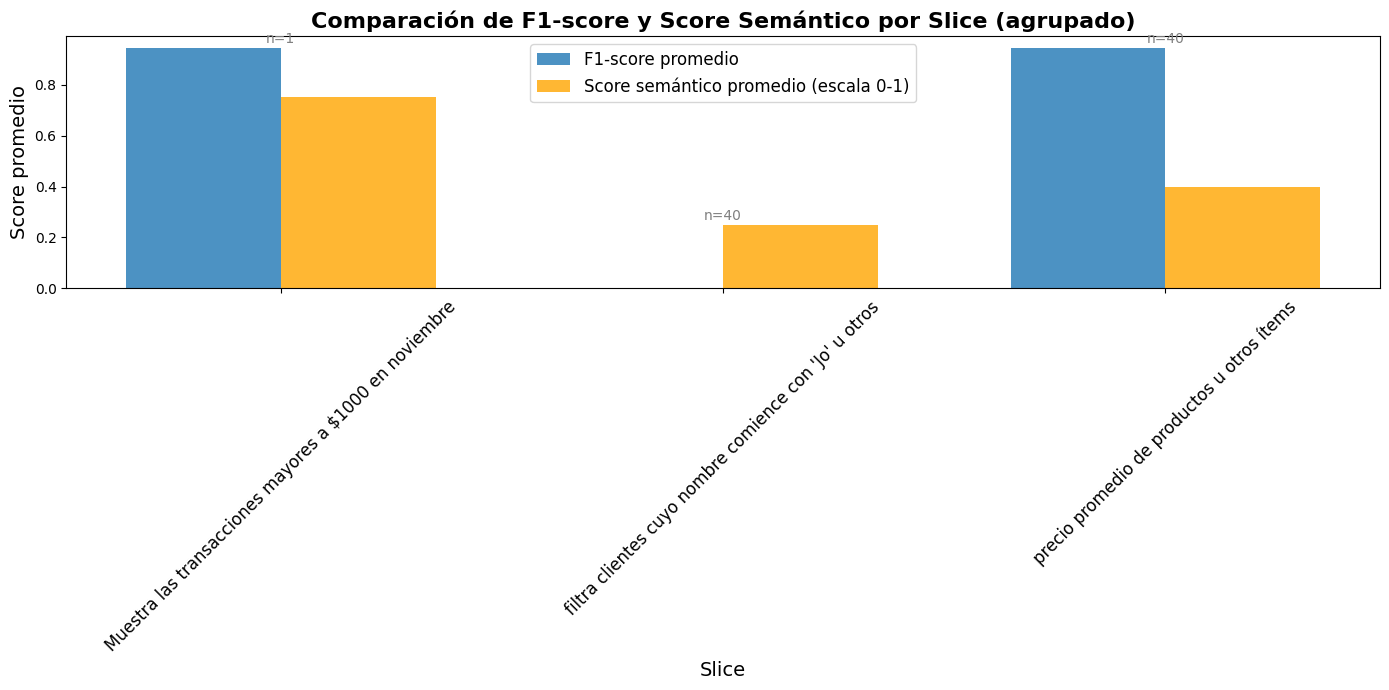

In [946]:
# Gráfica de F1-score y Score Semántico promedio por slice agrupado
import matplotlib.pyplot as plt

if len(resultados_individuales) > 0:
    df_resultados = pd.DataFrame(resultados_individuales)
    df_resultados['slice'] = df_resultados['slice'].apply(limpiar_nombre_slice)
    resumen = df_resultados.groupby('slice').agg({
        'f1_score': 'mean',
        'score_semantico': 'mean',
        'slice': 'count'
    }).rename(columns={'slice': 'Tamaño'}).reset_index()
    x = range(len(resumen['slice']))
    width = 0.35
    fig, ax1 = plt.subplots(figsize=(14, 7))
    bars1 = ax1.bar([i - width/2 for i in x], resumen['f1_score'], width, label='F1-score promedio', alpha=0.8)
    bars2 = ax1.bar([i + width/2 for i in x], resumen['score_semantico']/100, width, label='Score semántico promedio (escala 0-1)', alpha=0.8, color='orange')
    ax1.set_ylabel('Score promedio', fontsize=14)
    ax1.set_xlabel('Slice', fontsize=14)
    ax1.set_title('Comparación de F1-score y Score Semántico por Slice (agrupado)', fontsize=16, fontweight='bold')
    ax1.set_xticks(list(x))
    ax1.set_xticklabels(resumen['slice'], rotation=45, ha='center', fontsize=12)
    ax1.legend(fontsize=12)
    for i, tam in enumerate(resumen['Tamaño']):
        ax1.text(i, max(resumen['f1_score'][i], resumen['score_semantico'][i]/100)+0.02, f"n={tam}", ha='center', fontsize=10, color='gray')
    plt.tight_layout()
    plt.show()
